# 113年臺北市A1及A2類交通事故多維度分析

---

## 目錄
1. 環境設定
2. 資料載入與前處理
3. 代碼對照表
4. 時間分析
   - 4.1 月份分析
   - 4.2 時段分析
   - 4.3 時間熱力圖分析
5. 空間分析
   - 5.1 行政區統計
   - 5.2 行政區樹狀圖分析
6. 肇因分析
7. 車種分析
8. 肇因與車種交叉分析
9. 人員特性分析
   - 9.1 基本人員特性
   - 9.2 年齡分布進階分析（箱形圖/小提琴圖）
   - 9.3 甜甜圈圖與堆疊面積圖
10. 綜合摘要報告


## 1. 環境設定

匯入所需的套件並設定中文字體


In [1]:
# 匯入套件
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from datetime import datetime
import warnings
import os
warnings.filterwarnings('ignore')

print("✓ 套件匯入完成")


Matplotlib is building the font cache; this may take a moment.


✓ 套件匯入完成


Could not save font_manager cache [Errno 2] No such file or directory: '/Users/murphywang/.matplotlib/fontlist-v390.json.matplotlib-lock'


✓ 已清除 matplotlib 字體快取
✓ 找到中文字體：PingFang HK
✓ 已套用中文字體：PingFang HK

測試中文顯示：


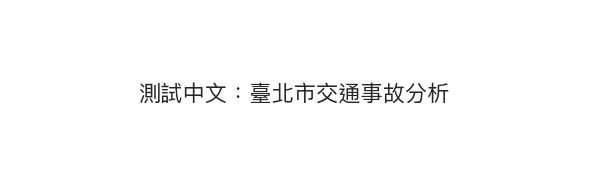

✓ 中文字體設定完成


In [2]:
# 設定中文字體
import platform
import matplotlib.font_manager as fm

# 清除 matplotlib 字體快取（重要！）
try:
    import shutil
    cache_dir = mpl.get_cachedir()
    if os.path.exists(cache_dir):
        shutil.rmtree(cache_dir)
        print("✓ 已清除 matplotlib 字體快取")
except:
    pass

# 重新載入字體管理器
fm._load_fontmanager(try_read_cache=False)

def setup_chinese_font():
    """自動偵測並設定中文字體"""
    system = platform.system()
    
    # 根據作業系統選擇字體優先順序
    if system == 'Darwin':  # macOS
        font_candidates = [
            'PingFang TC',        # 蘋方-繁（更適合繁體中文）
            'PingFang HK',        # 蘋方-香港
            'Heiti TC',           # 黑體-繁
            'STHeiti',            # 華文黑體
            'Arial Unicode MS'    # Arial Unicode MS
        ]
    elif system == 'Windows':
        font_candidates = [
            'Microsoft JhengHei', # 微軟正黑體
            'Microsoft YaHei',    # 微軟雅黑
            'SimHei',             # 黑體
            'KaiTi'               # 楷體
        ]
    else:  # Linux
        font_candidates = [
            'Noto Sans CJK TC',
            'WenQuanYi Micro Hei',
            'WenQuanYi Zen Hei',
            'Droid Sans Fallback'
        ]
    
    # 獲取系統可用字體列表
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    # 找到第一個可用的中文字體
    for font in font_candidates:
        if font in available_fonts:
            print(f"✓ 找到中文字體：{font}")
            return font
    
    print("⚠ 警告：未找到理想的中文字體，使用系統預設")
    return None

# 設定字體
selected_font = setup_chinese_font()

if selected_font:
    # 明確設定所有 matplotlib 的字體參數
    plt.rcParams['font.sans-serif'] = [selected_font, 'DejaVu Sans']
    plt.rcParams['font.family'] = 'sans-serif'
    mpl.rcParams['font.sans-serif'] = [selected_font, 'DejaVu Sans']
    mpl.rcParams['font.family'] = 'sans-serif'
    print(f"✓ 已套用中文字體：{selected_font}")
else:
    # 備用方案
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
    mpl.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
    print("✓ 使用備用字體：Arial Unicode MS")

# 解決負號顯示問題
plt.rcParams['axes.unicode_minus'] = False
mpl.rcParams['axes.unicode_minus'] = False

# 設定繪圖風格（放在字體設定之後很重要）
sns.set_style('whitegrid')

# 再次確認字體設定（因為 seaborn 可能會覆蓋）
if selected_font:
    plt.rcParams['font.sans-serif'] = [selected_font, 'DejaVu Sans']
    mpl.rcParams['font.sans-serif'] = [selected_font, 'DejaVu Sans']

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 6)

# 測試中文顯示
print("\n測試中文顯示：")
fig, ax = plt.subplots(figsize=(6, 2))
ax.text(0.5, 0.5, '測試中文：臺北市交通事故分析', 
        fontsize=16, ha='center', va='center')
ax.axis('off')
plt.tight_layout()
plt.show()
print("✓ 中文字體設定完成")


In [3]:
# 建立輸出目錄
if not os.path.exists('分析結果'):
    os.makedirs('分析結果')
if not os.path.exists('分析結果/圖表'):
    os.makedirs('分析結果/圖表')
if not os.path.exists('分析結果/統計表'):
    os.makedirs('分析結果/統計表')


## 2. 資料載入與前處理


In [4]:
print("\n【步驟1】資料載入...")
df = pd.read_csv("113年-臺北市A1及A2類交通事故明細.csv", encoding='big5')
print(f"✓ 資料總筆數（當事人）：{len(df):,}")
print(f"✓ 資料欄位數：{len(df.columns)}")

# ⚠️ 重要：區分「當事人筆數」與「事故件數」
# 當事人序號=1 的筆數 = 事故件數
first_party = df[df['當事人序號'] == 1].copy()
accident_count = len(first_party)
print(f"✓ 事故件數（第一當事人）：{accident_count:,}")

# A1/A2 分類
a1_count = len(first_party[first_party['處理別-編號'] == 1])
a2_count = len(first_party[first_party['處理別-編號'] == 2])
print(f"  - A1類事故：{a1_count}件")
print(f"  - A2類事故：{a2_count:,}件")

# 顯示前幾筆資料
df.head()



【步驟1】資料載入...
✓ 資料總筆數（當事人）：51,810
✓ 資料欄位數：50
✓ 事故件數（第一當事人）：22,368
  - A1類事故：68件
  - A2類事故：22,300件


,發生年度,發生月,發生日,發生時-Hours,發生分,處理別-編號,區序,肇事地點,死亡人數,2-30日死亡人數,...,駕駛執照種類,飲酒情形,車輛撞擊部位1,車輛撞擊部位2,肇因碼-個別,肇因碼-主要,個人肇逃否,職業,座標-X,座標-Y
0,113,1,1,0,22,2,07信義區,信義區基隆路1段147巷5弄11號,0.0,0.0,...,10.0,1.0,11.0,NaN,4.0,NaN,1.0,21.0,121.566408,25.043090
1,113,1,1,0,22,2,07信義區,信義區基隆路1段147巷5弄11號,0.0,0.0,...,20.0,10.0,16.0,NaN,60.0,NaN,1.0,22.0,121.566408,25.043090
2,113,1,1,0,36,2,05中正區,中正區信義路2段與信義路2段181巷口,0.0,0.0,...,8.0,2.0,8.0,NaN,80.0,NaN,1.0,21.0,121.529308,25.033923
3,113,1,1,0,36,2,05中正區,中正區信義路2段與信義路2段181巷口,0.0,0.0,...,9.0,2.0,12.0,NaN,44.0,NaN,1.0,21.0,121.529308,25.033923
4,113,1,1,0,45,2,06松山區,松山區八德路4段389巷與南京東路5段250巷18弄口,0.0,0.0,...,20.0,10.0,16.0,NaN,67.0,NaN,1.0,21.0,121.568319,25.050199


In [5]:
# 基本統計（與官方報告一致的統計方式）
print("\n【步驟2】基本統計（以事故為單位）...")

# 死亡/受傷人數應以事故第一當事人欄位統計（每事故只計一次）
total_deaths = first_party['死亡人數'].sum()
total_2_30_deaths = first_party['2-30日死亡人數'].sum()
total_injuries = first_party['受傷人數'].sum()

print(f"✓ 死亡人數（24小時內）：{total_deaths:,.0f}")
print(f"✓ 2-30日死亡人數：{total_2_30_deaths:,.0f}")
print(f"✓ 受傷人數：{total_injuries:,.0f}")
print(f"✓ 總傷亡人數：{(total_deaths + total_2_30_deaths + total_injuries):,.0f}")

# 顯示與官方報告一致性檢查
print("\n📊 與官方報告數據比對：")
print("  官方報告：A1類68件、A2類22,300件、死亡70人、受傷29,774人")
print(f"  本分析：A1類{a1_count}件、A2類{a2_count:,}件、死亡{total_deaths:.0f}人、受傷{total_injuries:,.0f}人")



【步驟2】基本統計（以事故為單位）...
✓ 死亡人數（24小時內）：70
✓ 2-30日死亡人數：4
✓ 受傷人數：29,774
✓ 總傷亡人數：29,848

📊 與官方報告數據比對：
  官方報告：A1類68件、A2類22,300件、死亡70人、受傷29,774人
  本分析：A1類68件、A2類22,300件、死亡70人、受傷29,774人


## 3. 代碼對照表


In [6]:
# 肇因碼對照表（依據道路交通事故調查報告表 112.7.1 後適用版本）
# ⚠️ 注意：113年資料適用 112.7.1 後版本，代碼範圍為 01-131
cause_map = {
    # (一) 駕駛者
    '1': '違規超車',
    '2': '爭(搶)道行駛',
    '4': '逆向行駛',
    '5': '未靠右行駛',
    '8': '左轉彎未依規定',
    '9': '右轉彎未依規定',
    '10': '迴轉未依規定',
    '11': '橫越道路不慎',
    '12': '倒車未依規定',
    '13': '超速駕駛',
    '14': '未依規定減速',
    '16': '未保持行車安全距離',
    '17': '未保持行車安全間隔',
    '18': '停車操作時未注意安全',
    '19': '起步時未注意安全',
    '20': '吸食違禁物駕駛',
    '21': '酒醉（後）駕駛',
    '22': '患病或服用藥物（疲勞）駕駛',
    '24': '搶（闘）越平交道',
    # 112.7.1 後新增 - 未依規定讓車細分
    '68': '危險駕駛',
    '69': '未遵守依法令授權交通指揮人員之指揮',
    '70': '車輛未依規定暫停讓行人先行',
    '71': '有號誌路口，轉彎車未讓直行車先行',
    '72': '無號誌路口，支線道未讓幹線道先行',
    '73': '無號誌路口，少線道未讓多線道先行',
    '74': '無號誌路口，轉彎車未讓直行車先行',
    '75': '無號誌路口，左方車未讓右方車先行',
    '76': '山路會車，靠山壁車未讓外緣車先行',
    '77': '峻狹坡路會車，下坡車未讓上坡車先行',
    '78': '行經圓環未依規定讓車',
    '79': '未依規定避讓執行緊急任務車',
    '80': '其他未依規定讓車',
    # 112.7.1 後新增 - 違反號誌細分
    '81': '闘紅燈直行',
    '82': '闘紅燈右轉',
    '83': '闘紅燈左轉（或迴轉）',
    '84': '違反閃光號誌',
    '85': '違反其他號誌',
    # 112.7.1 後新增 - 違反標誌標線細分
    '86': '違反遵行方向標誌（線）',
    '87': '違反車輛專用標誌（線）',
    '88': '違反行人專用標誌（線）',
    '89': '違反禁止進入標誌',
    '90': '違反禁止各種車輛進入標誌',
    '91': '違反禁止會車標誌',
    '92': '違反禁止迴轉或迴車標誌',
    '93': '違反車輛改道標誌',
    '94': '違反禁止超車標誌（線）',
    '95': '違反禁止變換車道標線',
    '96': '違反二段式左（右）轉標誌（線）',
    '97': '違反禁行車種標誌（字）',
    '98': '違反禁止左轉、右轉標誌',
    '99': '違反其他標誌（線）禁制',
    # 112.7.1 後新增 - 其他駕駛行為
    '100': '變換車道不當',
    '101': '方向不定（不包括危險駕車）',
    '102': '閃避不當（慎）',
    '103': '多車道迴轉，未先駛入內側車道',
    # 112.7.1 後新增 - 分心駕駛細分
    '104': '打瞌睡或疲勞駕駛',
    '105': '飲食、抽菸、拿物品分心駕駛',
    '106': '乘客、車上動物干擾分心駕駛',
    '107': '觀看其他事故、活動、道路環境分心駕駛',
    '108': '恍神、緊張、心不在焉分心駕駛',
    '109': '使用車輛自動駕駛或先進駕駛輔助系統設備不符規定',
    '110': '操作、觀看行車輔助或娛樂性顯示設備',
    '111': '使用手持行動電話',
    '112': '未保持平交道淨空',
    # (二) 燈光
    '27': '未依規定使用燈光',
    '28': '暗處停車無燈光、標識',
    '29': '夜間行駛無燈光設備',
    # (三) 裝載
    '30': '裝載貨物不穩妥',
    '31': '載運貨物超重',
    '32': '超載人員',
    '33': '載運貨物超長、寬、高',
    '34': '裝卸貨物不當',
    '35': '裝載未盡安全措施',
    '36': '未待乘客安全上下而開車',
    '37': '其他裝載不當',
    # (四) 其他
    '38': '違規（臨時）停車',
    '39': '車輛拋錨未採安全措施',
    '40': '開啟或關閉車門不當',
    '42': '其他不當駕車行為',
    '113': '車輛未停妥滑動致生事故',
    '114': '發生事故後未採取安全措施',
    '115': '被車輛輾壓之不明物體彈飛',
    '116': '車輛或機械操作不當（慎）',
    '117': '因光線、視線遮蔽致生事故',
    '118': '跡證不足且無影像，無法釐清肇因',
    '119': '肇事逃逸未查獲，無法查明肇因',
    # (五) 無（車輛駕駛者因素）
    '44': '尚未發現肇事因素（駕駛者）',
    # (六) 機件
    '45': '煞車失靈或故障',
    '46': '方向操縱系統故障',
    '47': '燈光系統故障',
    '48': '車輪脫落或輪胎爆裂',
    '49': '車輛零件脫落',
    '50': '其他機件失靈或故障',
    '120': '車輛附屬機具未盡安全措施',
    # (七) 非駕駛者
    '53': '穿越道路未注意左右來車',
    '54': '在道路上嬉戲或奔走不定',
    '55': '未待車輛停妥而上下車',
    '56': '上下車輛時未注意安全',
    '57': '頭手伸出車外',
    '58': '乘坐不當（慎）',
    '59': '在道路上工作未設適當標識',
    '60': '其他引起事故之疏失或行為',
    '121': '未依標誌或標線穿越道路',
    '122': '未依號誌或手勢指揮穿越道路',
    '123': '未依規定行走地下道、天橋穿越道路',
    '124': '搶（闘）越平交道',
    '125': '事故發生時當事者逕自離開現場',
    '126': '開啟或關閉車門不當',
    '127': '指揮不當(包括未依法令授權)',
    # (八) 交通管制(設施)
    '61': '路況危險無安全（警告）設施',
    '62': '交通管制設施失靈或損毀',
    '64': '平交道看守疏失或未放柵欄',
    '65': '其他交通管制不當',
    '128': '施工安全防護措施未依規定或未盡完善',
    # (九) 無（物或動物）
    '66': '動物竄出',
    '67': '尚未發現肇事因素（非駕駛者）',
    '129': '道路設施、植栽或其他裝置，倒塌或掉落',
    '130': '物品滾滑行或飛掉落',
    '131': '強風、暴雨、濃霧（煙）'
}

# 車種代碼對照表（依據道路交通事故調查報告表 112.7.1 後適用版本）
vehicle_map = {
    # (一) 大客車
    'A01': '公營公車',
    'A02': '民營公車',
    'A03': '公營客運',
    'A04': '民營客運',
    'A05': '遊覽車',
    'A06': '自用大客車',
    # (二) 大貨車（含客、貨兩用）
    'A11': '營業用大貨車',
    'A12': '自用大貨車',
    # (三) 全聯結車
    'A21': '營業用全聯結車',
    'A22': '自用全聯結車',
    # (四) 半聯結車
    'A31': '營業用半聯結車',
    'A32': '自用半聯結車',
    # (五) 曳引車
    'A41': '營業用曳引車',
    'A42': '自用曳引車',
    # (六) 小客車（含客、貨兩用）
    'B01': '計程車',
    'B02': '租賃車',
    'B03': '自用小客車',
    # (七) 小貨車（含客、貨兩用）
    'B11': '營業用小貨車',
    'B12': '自用小貨車',
    'B13': '租賃小貨車',  # 112.7.1 後新增
    # (八) 機車
    'C01': '大型重型機車1(550C.C.以上)',
    'C02': '大型重型機車2(250-550C.C.)',
    'C03': '普通重型機車',
    'C04': '普通輕型機車',
    'C05': '小型輕型機車',
    # (九) 軍車
    'D01': '軍用大客車',
    'D02': '軍用載重車',
    'D03': '軍用小型車',
    # (十) 特種車
    'E01': '救護車',
    'E02': '消防車',
    'E03': '警備車',
    'E04': '工程車',
    'E05': '其他特種車',
    # (十一) 慢車
    'F01': '腳踏自行車',
    'F02': '電動輔助自行車',
    'F03': '微型電動二輪車',  # 112.7.1 後更名（原：電動自行車）
    'F04': '人力車',
    'F05': '獸力車',
    'F06': '其他慢車',
    'F07': '個人行動運具',  # 112.7.1 後新增
    # (十二) 其他車
    'G01': '拼裝車',
    'G02': '農耕用車(或機械)',
    'G03': '動力機械',
    'G04': '拖車(架)',
    'G05': '火車',
    'G06': '其他車',
    'G07': '大眾捷運系統車輛',  # 112.7.1 後新增
    # (十三) 人
    'H01': '行人',
    'H02': '乘客',
    'H03': '其他人',
    'H04': '輔助代步器材'  # 112.7.1 後新增
}

print("✓ 代碼對照表已建立（依據 112.7.1 後適用版本）")
print(f"  - 肇因碼：共 {len(cause_map)} 個代碼（01-131）")
print(f"  - 車種代碼：共 {len(vehicle_map)} 個代碼")


✓ 代碼對照表已建立（依據 112.7.1 後適用版本）
  - 肇因碼：共 119 個代碼（01-131）
  - 車種代碼：共 51 個代碼


## 4. 時間分析

### 4.1 月份分析


In [7]:
print("\n【步驟3】時間分析...")

# 月份統計（⚠️ 使用 first_party 統計事故件數）
month_stats = first_party.groupby('發生月').agg({
    '發生月': 'count',
    '死亡人數': 'sum',
    '受傷人數': 'sum'
}).rename(columns={'發生月': '事故件數'})
month_stats['傷亡總計'] = month_stats['死亡人數'] + month_stats['受傷人數']
month_stats['平均傷亡/件'] = (month_stats['傷亡總計'] / month_stats['事故件數']).round(2)

# 儲存月份統計
month_stats.to_csv('分析結果/統計表/月份統計.csv', encoding='utf-8-sig')
print("✓ 月份統計表已儲存")

# 顯示統計表
month_stats



【步驟3】時間分析...
✓ 月份統計表已儲存


,事故件數,死亡人數,受傷人數,傷亡總計,平均傷亡/件
發生月,,,,,
1,2089,5.0,2775.0,2780.0,1.33
2,1600,8.0,2159.0,2167.0,1.35
3,1911,9.0,2561.0,2570.0,1.34
4,1764,1.0,2340.0,2341.0,1.33
5,1943,8.0,2638.0,2646.0,1.36
6,1781,3.0,2369.0,2372.0,1.33
7,1828,5.0,2412.0,2417.0,1.32
8,1913,6.0,2595.0,2601.0,1.36
9,1934,4.0,2509.0,2513.0,1.30


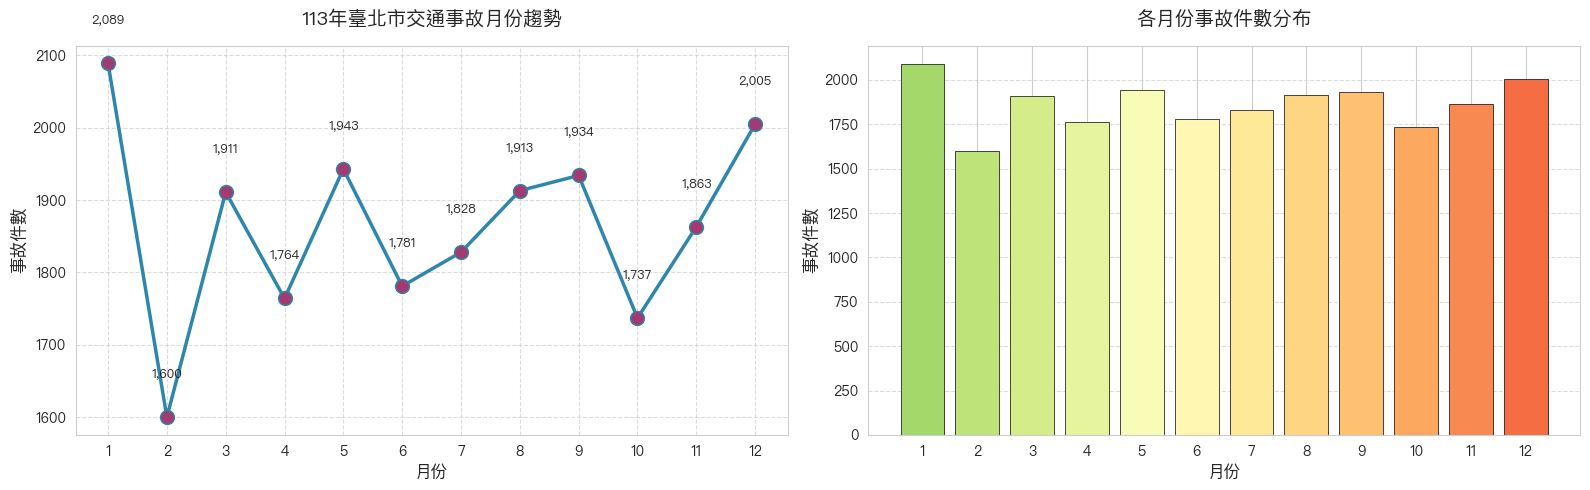

✓ 月份分析圖表已儲存


In [8]:
# 繪製月份圖表
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 折線圖（⚠️ 使用 first_party 統計事故件數）
month_counts = first_party['發生月'].value_counts().sort_index()
axes[0].plot(month_counts.index, month_counts.values, marker='o', linewidth=2.5, 
             markersize=10, color='#2E86AB', markerfacecolor='#A23B72')
axes[0].set_title('113年臺北市交通事故月份趨勢', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('月份', fontsize=12)
axes[0].set_ylabel('事故件數', fontsize=12)
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, linestyle='--', alpha=0.7)

for x, y in zip(month_counts.index, month_counts.values):
    axes[0].text(x, y + 50, f'{y:,}', ha='center', va='bottom', fontsize=9)

# 長條圖
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.8, 12))
axes[1].bar(month_counts.index, month_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('各月份事故件數分布', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('月份', fontsize=12)
axes[1].set_ylabel('事故件數', fontsize=12)
axes[1].set_xticks(range(1, 13))
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('分析結果/圖表/01_月份分析.png', bbox_inches='tight')
plt.show()
print("✓ 月份分析圖表已儲存")


### 4.2 時段分析


In [9]:
# 定義時段分類函數
def classify_time_period(hour):
    if 0 <= hour <= 5:
        return '清晨 (00:00-05:59)'
    elif 6 <= hour <= 11:
        return '上午 (06:00-11:59)'
    elif 12 <= hour <= 17:
        return '下午 (12:00-17:59)'
    else:
        return '夜晚 (18:00-23:59)'

# 在 df 和 first_party 上都建立時段欄位
df['時段'] = df['發生時-Hours'].apply(classify_time_period)
first_party['時段'] = first_party['發生時-Hours'].apply(classify_time_period)

# ⚠️ 使用 first_party 統計事故件數
time_counts = first_party['時段'].value_counts()
hour_counts = first_party['發生時-Hours'].value_counts().sort_index()

# 儲存時段統計
time_stats = pd.DataFrame({
    '時段': time_counts.index,
    '事故件數': time_counts.values,
    '佔比(%)': (time_counts.values / len(first_party) * 100).round(2)
})
time_stats.to_csv('分析結果/統計表/時段統計.csv', index=False, encoding='utf-8-sig')
print("✓ 時段統計表已儲存")

# 顯示統計表
time_stats


✓ 時段統計表已儲存


,時段,事故件數,佔比(%)
0,上午 (06:00-11:59),7938,35.49
1,下午 (12:00-17:59),7790,34.83
2,夜晚 (18:00-23:59),5713,25.54
3,清晨 (00:00-05:59),927,4.14


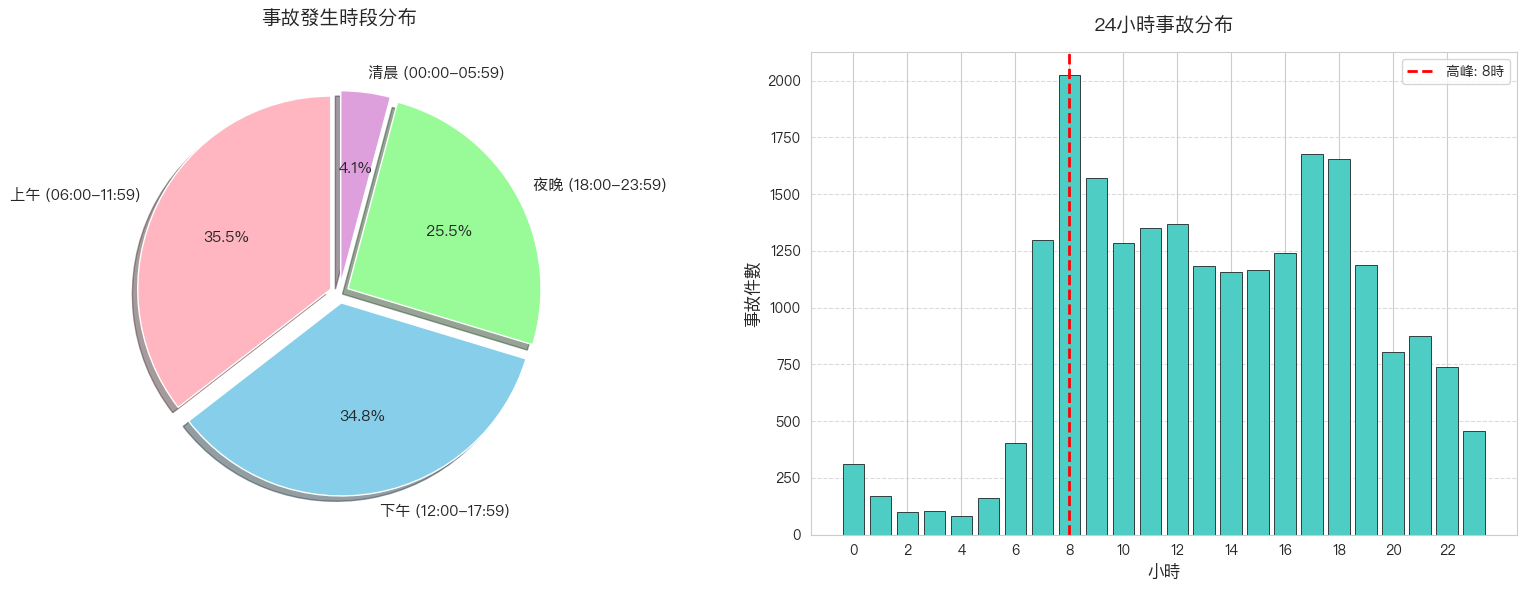

✓ 時段分析圖表已儲存


In [10]:
# 繪製時段圖表
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 圓餅圖
colors_pie = ['#FFB6C1', '#87CEEB', '#98FB98', '#DDA0DD']
explode = (0.05, 0.05, 0.05, 0.05)
wedges, texts, autotexts = axes[0].pie(time_counts, labels=time_counts.index, autopct='%1.1f%%',
                                         startangle=90, colors=colors_pie, explode=explode,
                                         shadow=True, textprops={'fontsize': 11, 'weight': 'bold'})
axes[0].set_title('事故發生時段分布', fontsize=14, fontweight='bold', pad=20)

# 24小時分布
axes[1].bar(hour_counts.index, hour_counts.values, color='#4ECDC4', edgecolor='black', linewidth=0.5)
axes[1].set_title('24小時事故分布', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('小時', fontsize=12)
axes[1].set_ylabel('事故件數', fontsize=12)
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].axvline(x=hour_counts.idxmax(), color='red', linestyle='--', linewidth=2, 
                label=f'高峰: {hour_counts.idxmax()}時')
axes[1].legend()

plt.tight_layout()
plt.savefig('分析結果/圖表/02_時段分析.png', bbox_inches='tight')
plt.show()
print("✓ 時段分析圖表已儲存")


### 4.3 時間熱力圖分析

透過熱力圖呈現「小時 × 星期」的事故分布，識別高風險時段


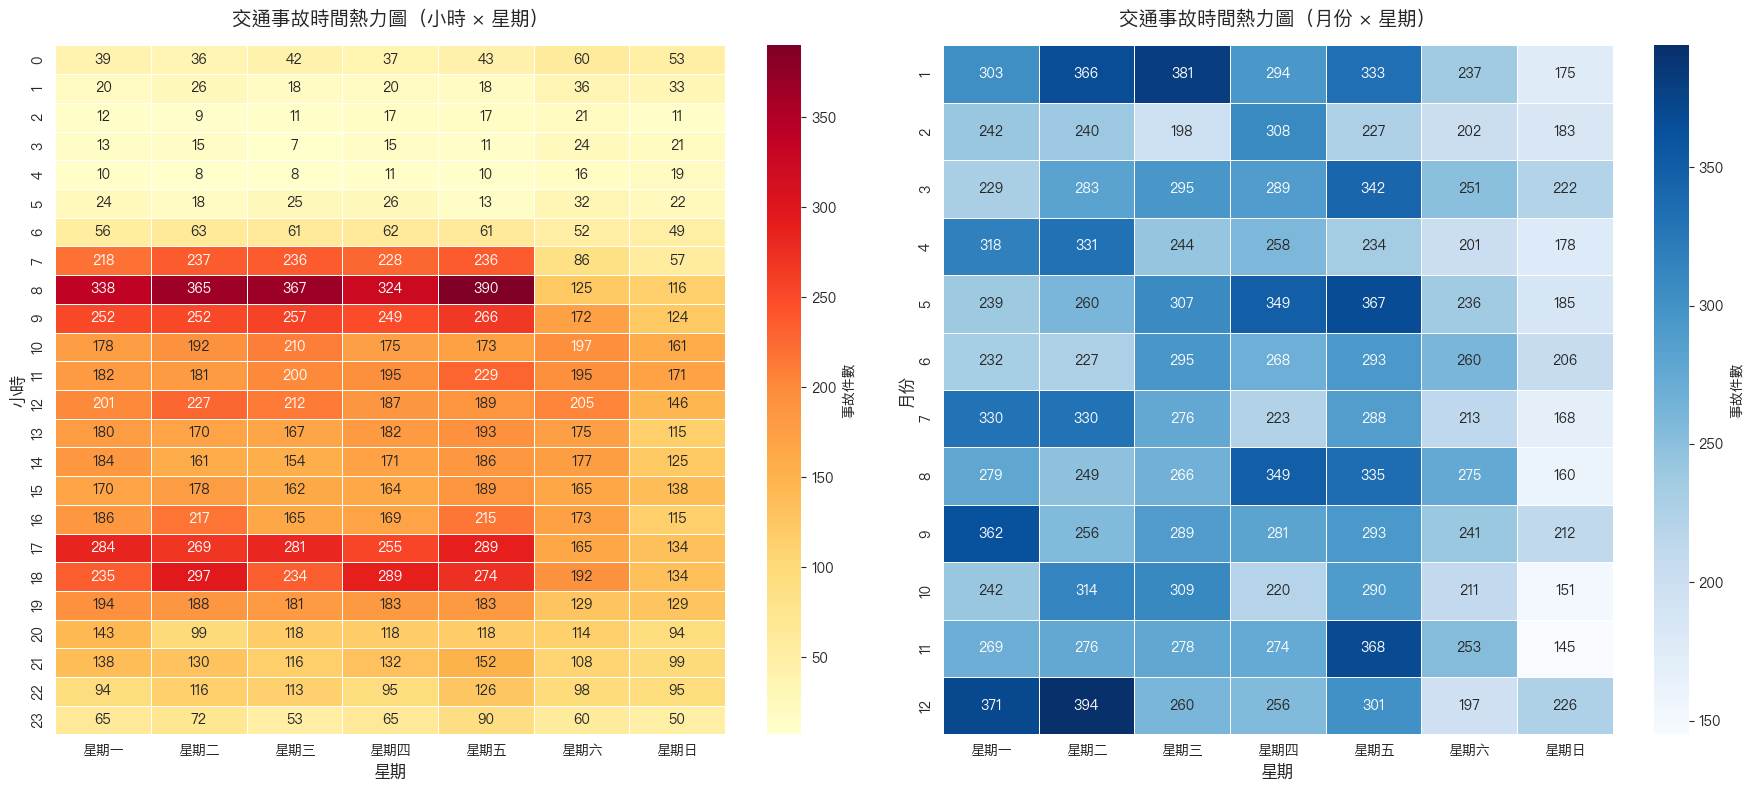

✓ 時間熱力圖已儲存

📊 分析發現：
   事故最高峰：8時 × 星期五，共 390 件
   平日總事故：17,380 件（日均 3,476 件）
   假日總事故：4,988 件（日均 2,494 件）


In [11]:
# 從年月日計算真正的星期幾
# 民國年轉換為西元年 (民國113年 = 西元2024年)
df['西元年'] = df['發生年度'] + 1911
first_party['西元年'] = first_party['發生年度'] + 1911

# 建立日期欄位並計算星期幾（在 df 和 first_party 上都建立）
df['日期'] = pd.to_datetime(df[['西元年', '發生月', '發生日']].rename(
    columns={'西元年': 'year', '發生月': 'month', '發生日': 'day'}))
df['星期數'] = df['日期'].dt.dayofweek  # 0=星期一, 6=星期日

first_party['日期'] = pd.to_datetime(first_party[['西元年', '發生月', '發生日']].rename(
    columns={'西元年': 'year', '發生月': 'month', '發生日': 'day'}))
first_party['星期數'] = first_party['日期'].dt.dayofweek

# 星期對照表
weekday_map = {0: '星期一', 1: '星期二', 2: '星期三', 3: '星期四', 
               4: '星期五', 5: '星期六', 6: '星期日'}
df['星期'] = df['星期數'].map(weekday_map)
first_party['星期'] = first_party['星期數'].map(weekday_map)

# ⚠️ 建立小時 × 星期 的交叉表（使用 first_party 統計事故件數）
heatmap_data = pd.crosstab(first_party['發生時-Hours'], first_party['星期數'])
# 確保欄位順序為星期一到星期日
heatmap_data = heatmap_data.reindex(columns=range(7), fill_value=0)
heatmap_data.columns = [weekday_map[col] for col in heatmap_data.columns]

# 繪製熱力圖
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 熱力圖 1：小時 × 星期
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='g', 
            linewidths=0.5, ax=axes[0], cbar_kws={'label': '事故件數'})
axes[0].set_title('交通事故時間熱力圖（小時 × 星期）', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('星期', fontsize=12)
axes[0].set_ylabel('小時', fontsize=12)

# 熱力圖 2：月份 × 星期（使用 first_party）
heatmap_month = pd.crosstab(first_party['發生月'], first_party['星期數'])
heatmap_month = heatmap_month.reindex(columns=range(7), fill_value=0)
heatmap_month.columns = [weekday_map[col] for col in heatmap_month.columns]

sns.heatmap(heatmap_month, cmap='Blues', annot=True, fmt='g',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '事故件數'})
axes[1].set_title('交通事故時間熱力圖（月份 × 星期）', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('星期', fontsize=12)
axes[1].set_ylabel('月份', fontsize=12)

plt.tight_layout()
plt.savefig('分析結果/圖表/08_時間熱力圖.png', bbox_inches='tight')
plt.show()
print("✓ 時間熱力圖已儲存")

# 找出事故高峰時段
max_idx = np.unravel_index(heatmap_data.values.argmax(), heatmap_data.values.shape)
max_hour = heatmap_data.index[max_idx[0]]
max_day = heatmap_data.columns[max_idx[1]]
max_count = heatmap_data.values.max()
print(f"\n📊 分析發現：")
print(f"   事故最高峰：{max_hour}時 × {max_day}，共 {max_count} 件")

# 計算平日與假日差異
weekday_total = heatmap_data[['星期一', '星期二', '星期三', '星期四', '星期五']].sum().sum()
weekend_total = heatmap_data[['星期六', '星期日']].sum().sum()
print(f"   平日總事故：{weekday_total:,} 件（日均 {weekday_total/5:,.0f} 件）")
print(f"   假日總事故：{weekend_total:,} 件（日均 {weekend_total/2:,.0f} 件）")


## 5. 空間分析

### 行政區統計


In [12]:
print("\n【步驟4】空間分析...")

# ⚠️ 使用 first_party（第一當事人）統計事故件數，與官方報告一致
# 注意：我們的資料只有 A1+A2，官方報告包含 A3，所以件數會不同
district_stats = first_party.groupby('區序').agg({
    '區序': 'count',
    '死亡人數': 'sum',
    '受傷人數': 'sum'
}).rename(columns={'區序': '事故件數'}).reset_index()
district_stats.columns = ['行政區', '事故件數', '死亡人數', '受傷人數']
district_stats = district_stats.sort_values('事故件數', ascending=False)
district_stats['佔比(%)'] = (district_stats['事故件數'] / accident_count * 100).round(2)
district_stats['累積佔比(%)'] = district_stats['佔比(%)'].cumsum().round(2)

# 儲存行政區統計
district_stats.to_csv('分析結果/統計表/行政區統計.csv', encoding='utf-8-sig')
print("✓ 行政區統計表已儲存")
print(f"📊 本資料僅含 A1+A2 類事故共 {accident_count:,} 件")

# 顯示統計表
district_stats



【步驟4】空間分析...
✓ 行政區統計表已儲存
📊 本資料僅含 A1+A2 類事故共 22,368 件


,行政區,事故件數,死亡人數,受傷人數,佔比(%),累積佔比(%)
2,03中山區,2932,4.0,3884.0,13.11,13.11
3,04大安區,2384,3.0,3111.0,10.66,23.77
4,05中正區,2207,6.0,2888.0,9.87,33.64
6,07信義區,2148,1.0,2744.0,9.60,43.24
11,12內湖區,2088,6.0,2698.0,9.33,52.57
7,08士林區,2081,8.0,2838.0,9.30,61.87
1,02萬華區,1760,16.0,2466.0,7.87,69.74
9,10文山區,1625,4.0,2168.0,7.26,77.00
0,01大同區,1507,7.0,2084.0,6.74,83.74
8,09北投區,1393,5.0,1943.0,6.23,89.97


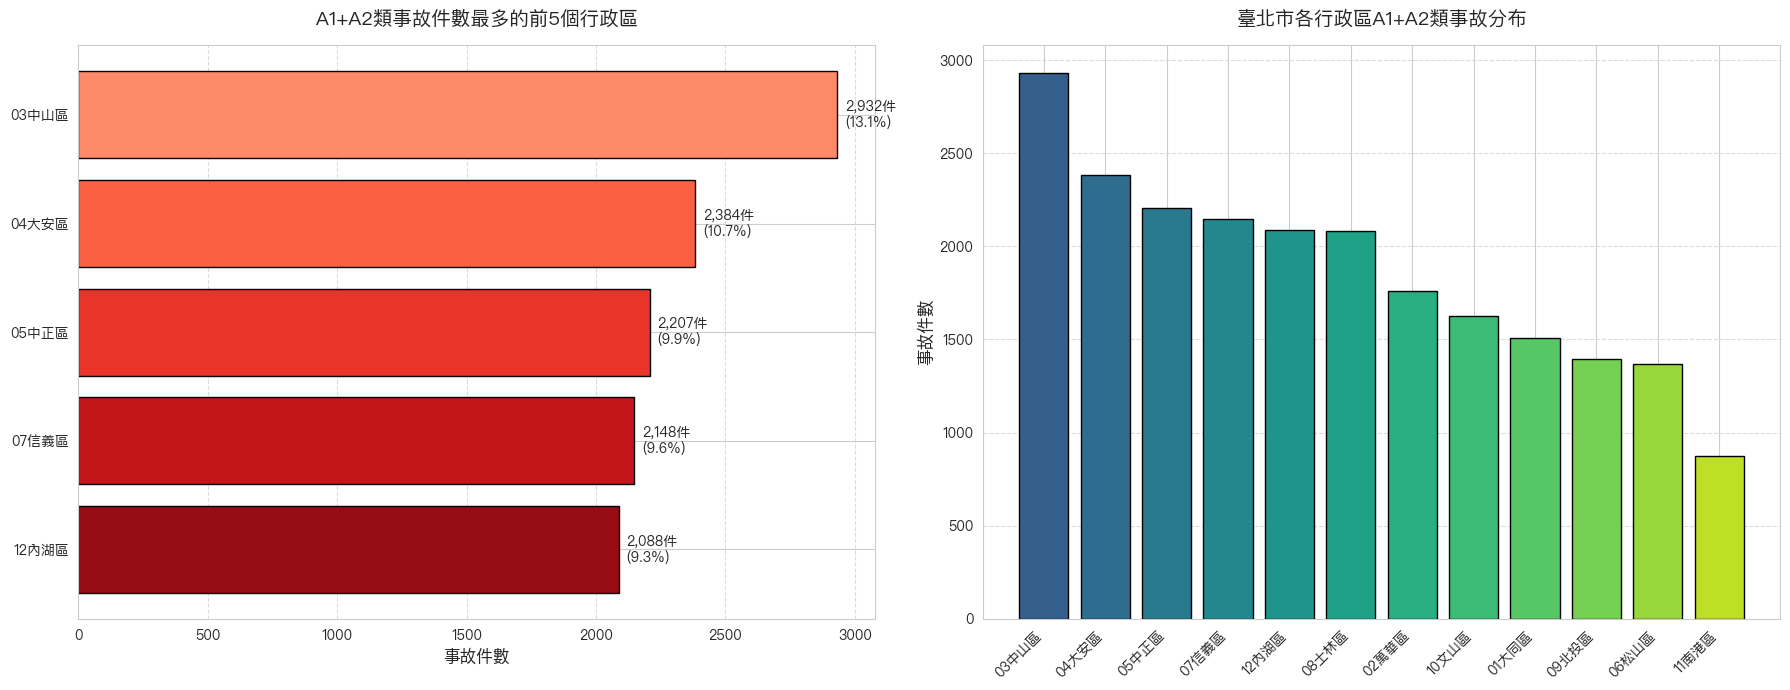

✓ 行政區分析圖表已儲存


In [13]:
# 繪製行政區圖表（使用 first_party 統計事故件數）
district_counts = first_party['區序'].value_counts()
top5_district = district_counts.head(5)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 5 行政區
colors_top5 = plt.cm.Reds(np.linspace(0.4, 0.9, 5))
bars = axes[0].barh(range(len(top5_district)), top5_district.values, color=colors_top5, edgecolor='black')
axes[0].set_yticks(range(len(top5_district)))
axes[0].set_yticklabels(top5_district.index)
axes[0].set_xlabel('事故件數', fontsize=12)
axes[0].set_title('A1+A2類事故件數最多的前5個行政區', fontsize=14, fontweight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

for i, (value, pct) in enumerate(zip(top5_district.values, top5_district.values/accident_count*100)):
    axes[0].text(value + 30, i, f'{value:,}件\n({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')

# 全部行政區
colors_all = plt.cm.viridis(np.linspace(0.3, 0.9, len(district_counts)))
axes[1].bar(range(len(district_counts)), district_counts.values, color=colors_all, edgecolor='black')
axes[1].set_xticks(range(len(district_counts)))
axes[1].set_xticklabels(district_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('事故件數', fontsize=12)
axes[1].set_title('臺北市各行政區A1+A2類事故分布', fontsize=14, fontweight='bold', pad=15)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('分析結果/圖表/03_行政區分析.png', bbox_inches='tight')
plt.show()
print("✓ 行政區分析圖表已儲存")


## 6. 肇因分析


### 5.2 行政區樹狀圖分析

使用樹狀圖呈現各行政區事故佔比的相對規模


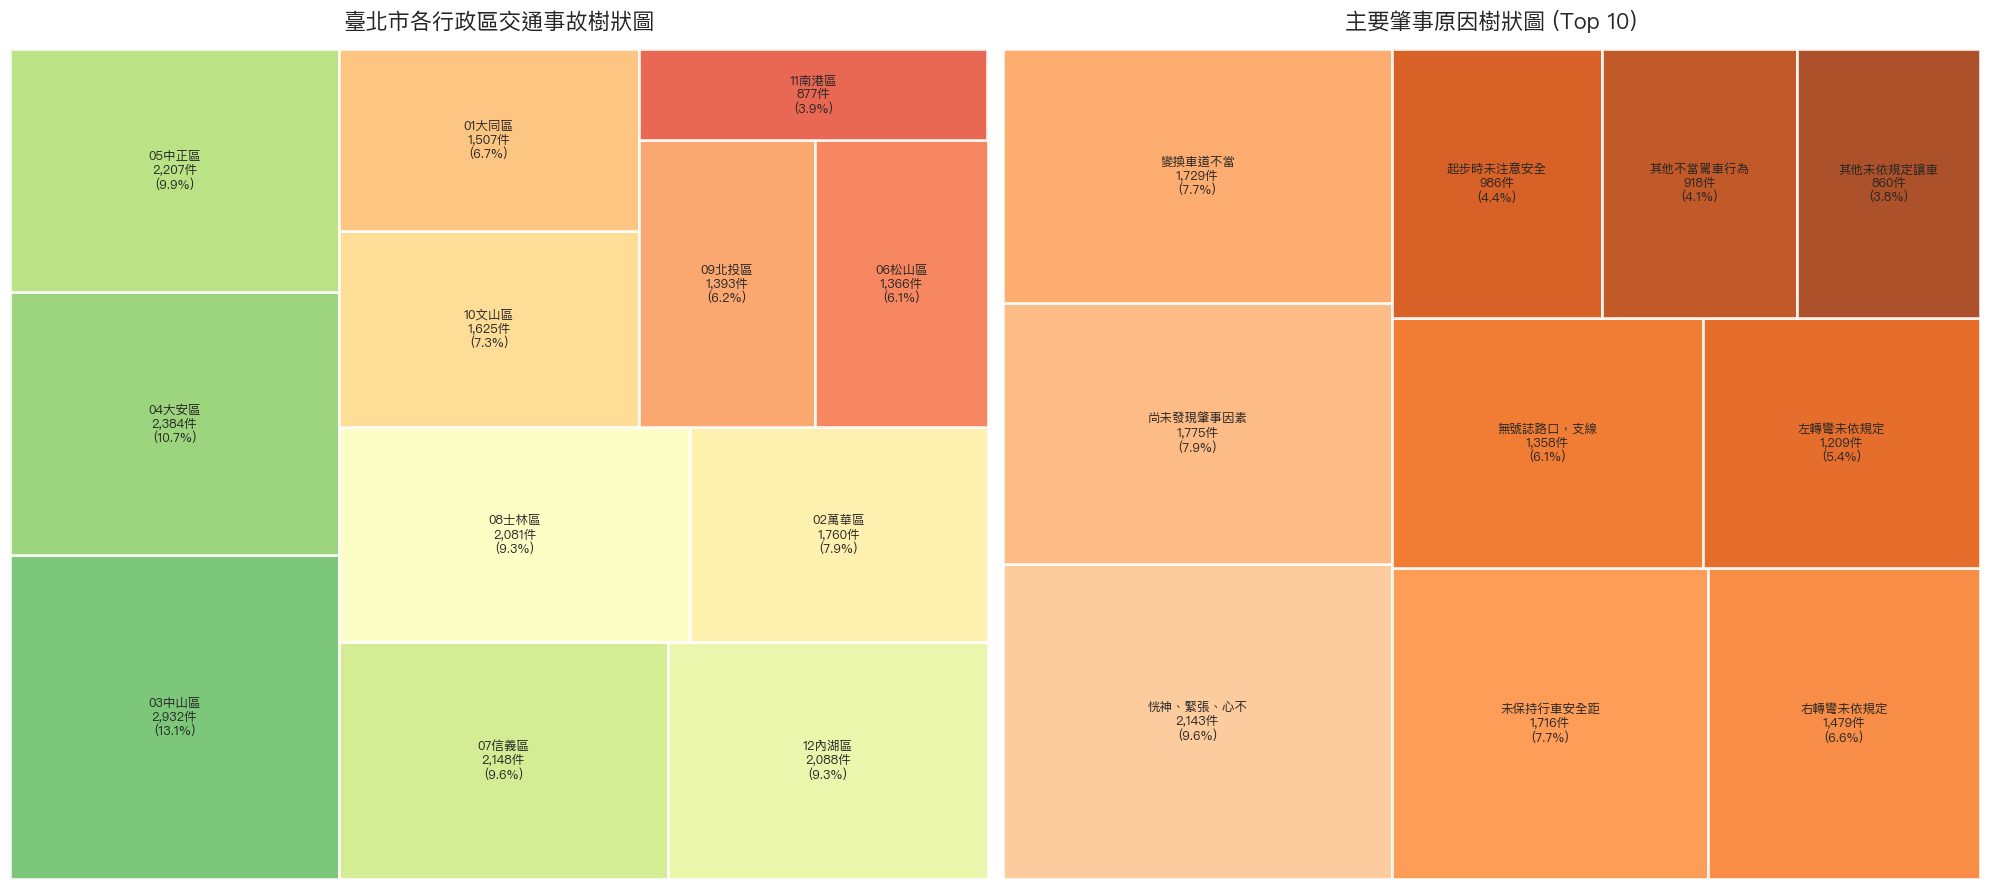

✓ 樹狀圖分析已儲存


In [14]:
# 安裝 squarify（如果尚未安裝）
try:
    import squarify
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'squarify'])
    import squarify

# 準備樹狀圖資料（⚠️ 使用第一當事人資料，與長條圖統計口徑一致）
district_counts = first_party['區序'].value_counts()
labels = [f'{name}\n{count:,}件\n({count/len(first_party)*100:.1f}%)' 
          for name, count in district_counts.items()]

# 設定顏色 - 使用漸層色彩
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.85, len(district_counts)))

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# 樹狀圖 1：行政區事故分布
squarify.plot(sizes=district_counts.values, label=labels, color=colors, 
              alpha=0.85, ax=axes[0], text_kwargs={'fontsize': 9, 'weight': 'bold'},
              edgecolor='white', linewidth=2)
axes[0].set_title('臺北市各行政區交通事故樹狀圖', fontsize=16, fontweight='bold', pad=15)
axes[0].axis('off')

# 樹狀圖 2：主要肇因分布（⚠️ 使用第一當事人資料，才能反映真正肇事原因）
cause_counts_top10 = first_party['肇因碼-個別'].value_counts().head(10)
cause_labels = [f'{cause_map.get(str(int(code)), f"代碼{int(code)}")[:8]}\n{count:,}件\n({count/len(first_party)*100:.1f}%)' 
                for code, count in cause_counts_top10.items()]
colors_cause = plt.cm.Oranges(np.linspace(0.3, 0.9, len(cause_counts_top10)))

squarify.plot(sizes=cause_counts_top10.values, label=cause_labels, color=colors_cause,
              alpha=0.85, ax=axes[1], text_kwargs={'fontsize': 9, 'weight': 'bold'},
              edgecolor='white', linewidth=2)
axes[1].set_title('主要肇事原因樹狀圖 (Top 10)', fontsize=16, fontweight='bold', pad=15)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('分析結果/圖表/09_樹狀圖分析.png', bbox_inches='tight')
plt.show()
print("✓ 樹狀圖分析已儲存")


In [15]:
print("\n【步驟5】肇因分析...")

# ⚠️ 重要：只統計「第一當事人」的肇因，與官方報告一致
# 第一當事人 = 警方初判肇事責任較重者
cause_counts = first_party['肇因碼-個別'].value_counts().head(15)
cause_counts_int = cause_counts.index.astype(int).astype(str)

# 建立肇因統計表
cause_stats = pd.DataFrame({
    '肇因碼': cause_counts_int,
    '肇因描述': [cause_map.get(code, f'代碼{code}') for code in cause_counts_int],
    '事故件數': cause_counts.values,
    '佔比(%)': (cause_counts.values / accident_count * 100).round(2)
})
cause_stats['累積佔比(%)'] = cause_stats['佔比(%)'].cumsum().round(2)
cause_stats.to_csv('分析結果/統計表/肇因統計.csv', index=False, encoding='utf-8-sig')
print("✓ 肇因統計表已儲存（僅統計第一當事人）")

# 顯示統計表
cause_stats



【步驟5】肇因分析...
✓ 肇因統計表已儲存（僅統計第一當事人）


,肇因碼,肇因描述,事故件數,佔比(%),累積佔比(%)
0,108,恍神、緊張、心不在焉分心駕駛,2143,9.58,9.58
1,44,尚未發現肇事因素（駕駛者）,1775,7.94,17.52
2,100,變換車道不當,1729,7.73,25.25
3,16,未保持行車安全距離,1716,7.67,32.92
4,9,右轉彎未依規定,1479,6.61,39.53
5,72,無號誌路口，支線道未讓幹線道先行,1358,6.07,45.60
6,8,左轉彎未依規定,1209,5.41,51.01
7,19,起步時未注意安全,986,4.41,55.42
8,42,其他不當駕車行為,918,4.10,59.52
9,80,其他未依規定讓車,860,3.84,63.36


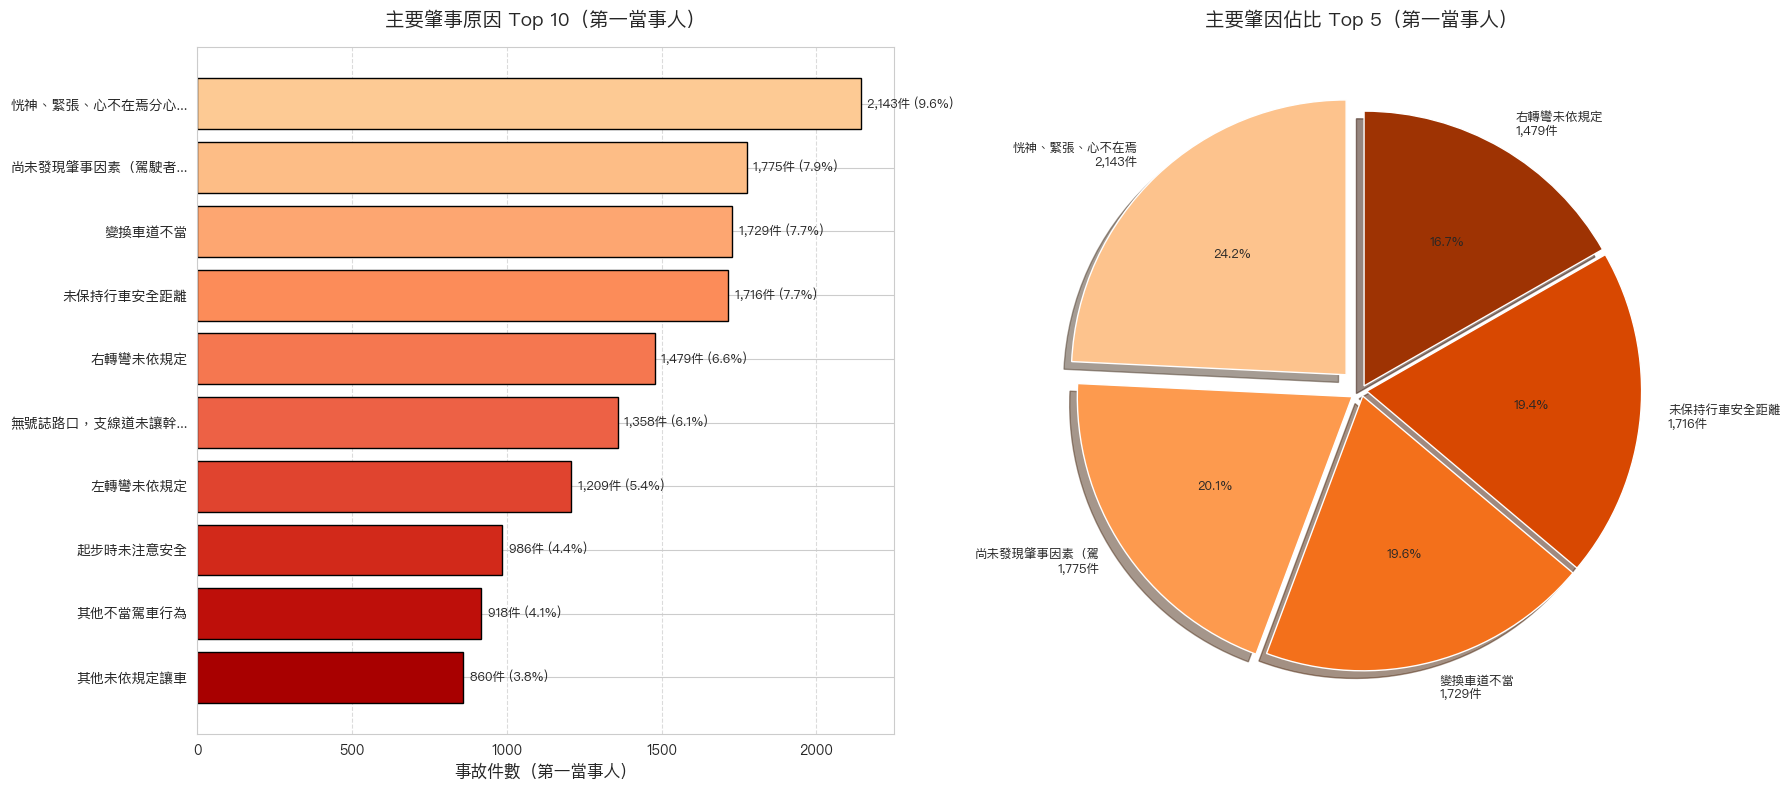

✓ 肇因分析圖表已儲存


In [16]:
# 繪製肇因圖表（使用第一當事人統計）
top10_cause = cause_counts.head(10)
top10_labels = [cause_map.get(str(int(code)), f'代碼{int(code)}') for code in top10_cause.index]
# 簡化標籤
short_labels = [label[:12] + '...' if len(label) > 12 else label for label in top10_labels]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 水平長條圖
colors_cause = plt.cm.OrRd(np.linspace(0.3, 0.9, 10))
bars = axes[0].barh(range(len(top10_cause)), top10_cause.values, color=colors_cause, edgecolor='black')
axes[0].set_yticks(range(len(top10_cause)))
axes[0].set_yticklabels(short_labels)
axes[0].set_xlabel('事故件數（第一當事人）', fontsize=12)
axes[0].set_title('主要肇事原因 Top 10（第一當事人）', fontsize=14, fontweight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

for i, value in enumerate(top10_cause.values):
    pct = value / accident_count * 100
    axes[0].text(value + 20, i, f'{value:,}件 ({pct:.1f}%)', va='center', fontsize=9)

# Top 5 圓餅圖
top5_cause = cause_counts.head(5)
top5_labels = [cause_map.get(str(int(code)), f'代碼{int(code)}')[:10] for code in top5_cause.index]
top5_labels_with_count = [f'{label}\n{count:,}件' for label, count in zip(top5_labels, top5_cause.values)]
colors_pie = plt.cm.Oranges(np.linspace(0.3, 0.9, 5))
explode = (0.08, 0.04, 0.02, 0.02, 0.02)
wedges, texts, autotexts = axes[1].pie(top5_cause, labels=top5_labels_with_count, autopct='%1.1f%%',
                                         startangle=90, colors=colors_pie, explode=explode,
                                         shadow=True, textprops={'fontsize': 9})
axes[1].set_title('主要肇因佔比 Top 5（第一當事人）', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('分析結果/圖表/04_肇因分析.png', bbox_inches='tight')
plt.show()
print("✓ 肇因分析圖表已儲存")


## 7. 車種分析


In [17]:
print("\n【步驟6】車種分析...")

# 車種統計
# ⚠️ 佔比計算使用「有車種記錄的當事人」為分母，與圓餅圖一致
vehicle_counts_all = df['車種'].value_counts()  # 所有有車種記錄的當事人
vehicle_counts = vehicle_counts_all.head(15)
vehicle_stats = pd.DataFrame({
    '車種代碼': vehicle_counts.index,
    '車種名稱': [vehicle_map.get(code, code) for code in vehicle_counts.index],
    '涉入件數': vehicle_counts.values,
    '佔比(%)': (vehicle_counts.values / vehicle_counts_all.sum() * 100).round(2)
})
vehicle_stats.to_csv('分析結果/統計表/車種統計.csv', index=False, encoding='utf-8-sig')
print("✓ 車種統計表已儲存")

# 顯示統計表
vehicle_stats



【步驟6】車種分析...
✓ 車種統計表已儲存


,車種代碼,車種名稱,涉入件數,佔比(%)
0,C03,普通重型機車,26539,52.15
1,B03,自用小客車,9966,19.58
2,H02,乘客,3380,6.64
3,B01,計程車,2866,5.63
4,H01,行人,1833,3.60
5,F01,腳踏自行車,1432,2.81
6,B12,自用小貨車,1138,2.24
7,B02,租賃車,902,1.77
8,C04,普通輕型機車,736,1.45
9,A02,民營公車,458,0.90


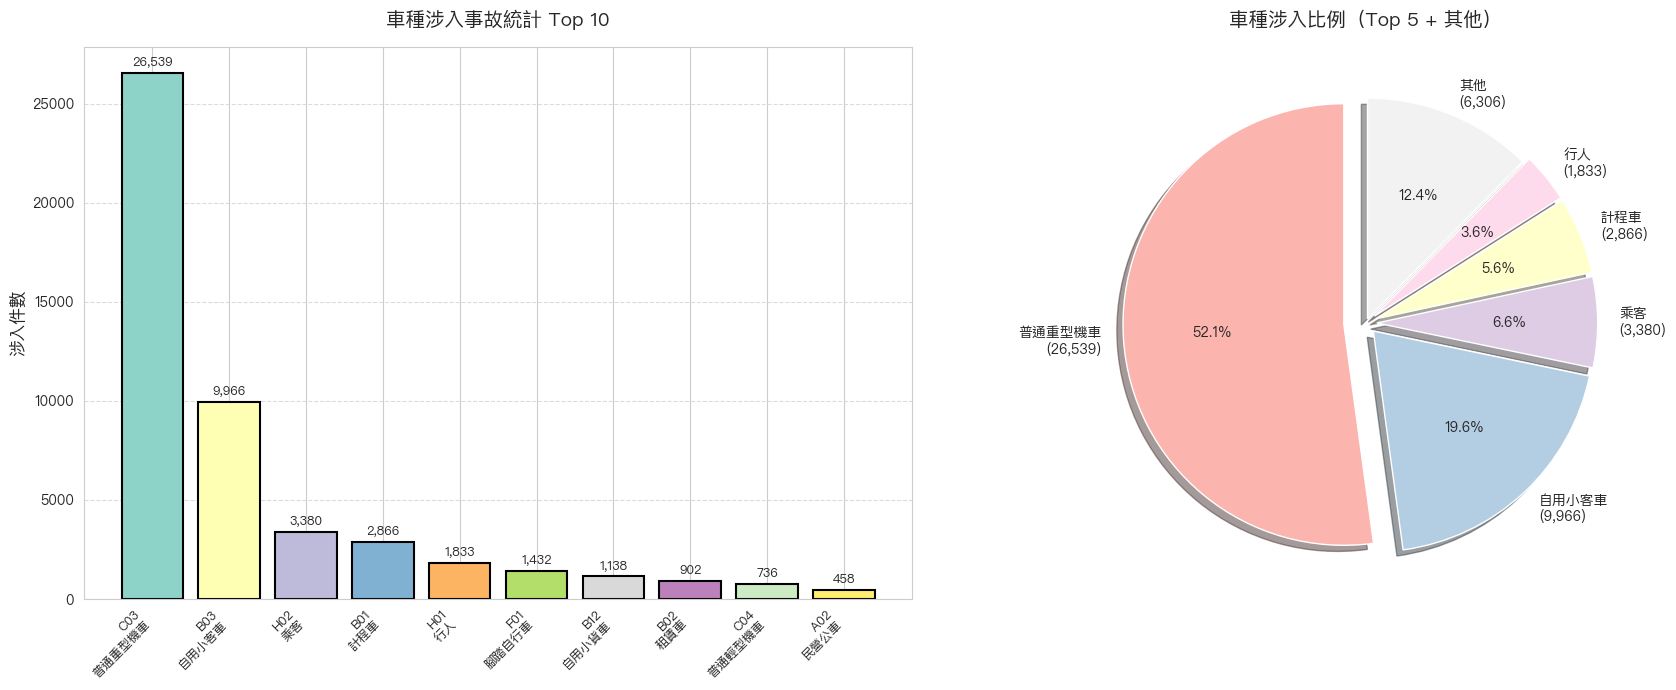

✓ 車種分析圖表已儲存


In [18]:
# 繪製車種圖表
top10_vehicle = vehicle_counts.head(10)
vehicle_labels = [f"{code}\n{vehicle_map.get(code, code)}" for code in top10_vehicle.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 長條圖
colors_vehicle = plt.cm.Set3(np.linspace(0, 1, len(top10_vehicle)))
axes[0].bar(range(len(top10_vehicle)), top10_vehicle.values, color=colors_vehicle, 
            edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(top10_vehicle)))
axes[0].set_xticklabels(vehicle_labels, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('涉入件數', fontsize=12)
axes[0].set_title('車種涉入事故統計 Top 10', fontsize=14, fontweight='bold', pad=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

for i, value in enumerate(top10_vehicle.values):
    axes[0].text(i, value + 200, f'{value:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 圓餅圖 (Top 5)
# ⚠️ 修正：「其他」應包含所有非 Top 5 的車種，而非只有排名 6-15
top5_vehicle = df['車種'].value_counts().head(5)
other_vehicle = df['車種'].value_counts()[5:].sum()
pie_data = pd.concat([top5_vehicle, pd.Series({'其他': other_vehicle})])
pie_labels = [vehicle_map.get(code, code) for code in pie_data.index[:5]] + ['其他']
pie_labels_with_count = [f"{label}\n({count:,})" for label, count in zip(pie_labels, pie_data.values)]

colors_pie = plt.cm.Pastel1(np.linspace(0, 1, 6))
explode = (0.1, 0.05, 0.05, 0.05, 0.05, 0.02)
wedges, texts, autotexts = axes[1].pie(pie_data, labels=pie_labels_with_count, autopct='%1.1f%%',
                                         startangle=90, colors=colors_pie, explode=explode,
                                         shadow=True, textprops={'fontsize': 10})
axes[1].set_title('車種涉入比例（Top 5 + 其他）', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('分析結果/圖表/05_車種分析.png', bbox_inches='tight')
plt.show()
print("✓ 車種分析圖表已儲存")


## 8. 肇因與車種交叉分析


In [19]:
print("\n【步驟7】肇因與車種交叉分析...")

# ⚠️ 統計說明：
# - 肇因篩選：使用 first_party（第一當事人）的 Top 5 肇因
# - 車種統計：使用 df（所有當事人）統計該肇因事故中各車種涉入人次
# - 意義：呈現「這類肇因的事故通常涉及哪些車種」（含肇事者與被撞方）

top5_cause_codes = cause_counts.head(5).index.astype(int)

# 建立交叉統計表
cross_stats = []
for cause_code in top5_cause_codes:
    cause_data = df[df['肇因碼-個別'] == cause_code]
    vehicle_dist = cause_data['車種'].value_counts().head(5)
    total = len(cause_data)
    
    cause_name = cause_map.get(str(cause_code), f'代碼{cause_code}')
    
    for idx, (veh_code, count) in enumerate(vehicle_dist.items(), 1):
        vehicle_name = vehicle_map.get(veh_code, veh_code)
        pct = count / total * 100
        cross_stats.append({
            '肇因碼': cause_code,
            '肇因描述': cause_name,
            '排名': idx,
            '車種代碼': veh_code,
            '車種名稱': vehicle_name,
            '涉入人次': count,
            '佔該肇因比例(%)': round(pct, 2)
        })

cross_df = pd.DataFrame(cross_stats)
cross_df.to_csv('分析結果/統計表/肇因車種交叉統計.csv', index=False, encoding='utf-8-sig')
print("✓ 肇因車種交叉統計表已儲存")

# 顯示統計表前20筆
cross_df.head(20)



【步驟7】肇因與車種交叉分析...
✓ 肇因車種交叉統計表已儲存


,肇因碼,肇因描述,排名,車種代碼,車種名稱,涉入人次,佔該肇因比例(%)
0,108,恍神、緊張、心不在焉分心駕駛,1,C03,普通重型機車,2363,66.62
1,108,恍神、緊張、心不在焉分心駕駛,2,B03,自用小客車,585,16.49
2,108,恍神、緊張、心不在焉分心駕駛,3,B01,計程車,162,4.57
3,108,恍神、緊張、心不在焉分心駕駛,4,F01,腳踏自行車,107,3.02
4,108,恍神、緊張、心不在焉分心駕駛,5,B12,自用小貨車,77,2.17
5,44,尚未發現肇事因素（駕駛者）,1,C03,普通重型機車,10095,64.79
6,44,尚未發現肇事因素（駕駛者）,2,B03,自用小客車,2838,18.21
7,44,尚未發現肇事因素（駕駛者）,3,B01,計程車,814,5.22
8,44,尚未發現肇事因素（駕駛者）,4,F01,腳踏自行車,380,2.44
9,44,尚未發現肇事因素（駕駛者）,5,B12,自用小貨車,248,1.59


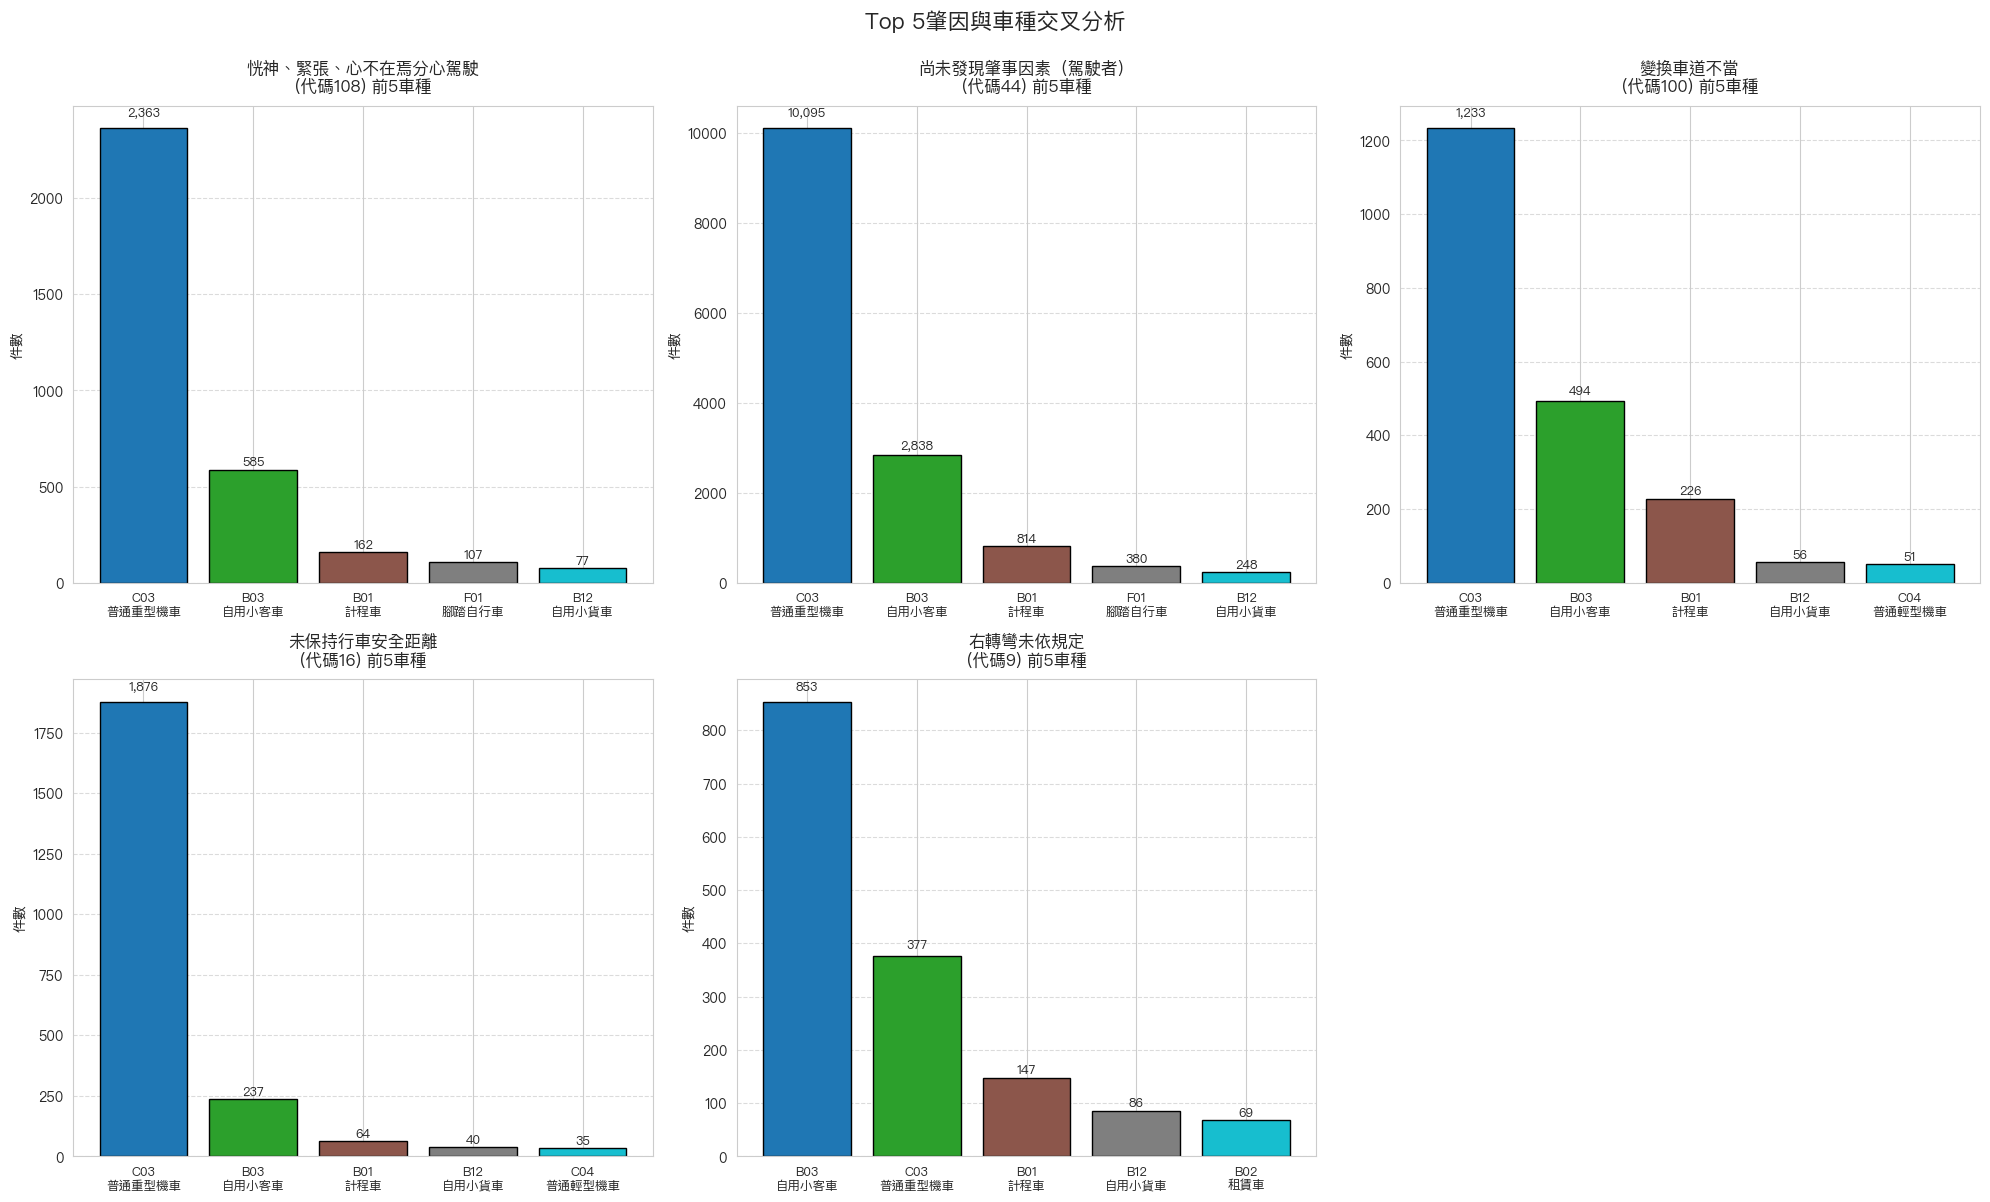

✓ 肇因車種交叉分析圖表已儲存


In [20]:
# 繪製交叉分析圖
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, cause_code in enumerate(top5_cause_codes):
    cause_data = df[df['肇因碼-個別'] == cause_code]
    vehicle_dist = cause_data['車種'].value_counts().head(5)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(vehicle_dist)))
    bars = axes[idx].bar(range(len(vehicle_dist)), vehicle_dist.values, color=colors, edgecolor='black')
    
    # 縮短標籤
    labels = []
    for code in vehicle_dist.index:
        veh_name = vehicle_map.get(code, code)
        if len(veh_name) > 6:
            labels.append(f"{code}\n{veh_name[:6]}")
        else:
            labels.append(f"{code}\n{veh_name}")
    
    axes[idx].set_xticks(range(len(vehicle_dist)))
    axes[idx].set_xticklabels(labels, rotation=0, fontsize=9)
    
    cause_name = cause_map.get(str(cause_code), f'代碼{cause_code}')
    # 縮短標題
    if len(cause_name) > 15:
        cause_name = cause_name[:15] + '...'
    axes[idx].set_title(f'{cause_name}\n(代碼{cause_code}) 前5車種', fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_ylabel('件數', fontsize=10)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.7)
    
    # 標註數值
    for bar, value in zip(bars, vehicle_dist.values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                      f'{value:,}', ha='center', va='bottom', fontsize=9)

# 隱藏最後一個子圖
axes[5].axis('off')

plt.suptitle('Top 5肇因與車種交叉分析', fontsize=16, y=0.998, fontweight='bold')
plt.tight_layout()
plt.savefig('分析結果/圖表/06_肇因車種交叉分析.png', bbox_inches='tight')
plt.show()
print("✓ 肇因車種交叉分析圖表已儲存")


## 9. 人員特性分析


In [21]:
print("\n【步驟8】人員特性分析...")

# 性別統計
gender_map = {1: '男性', 2: '女性'}
gender_counts = df['性別'].value_counts()
gender_stats = pd.DataFrame({
    '性別代碼': gender_counts.index,
    '性別': [gender_map.get(int(code), f'代碼{int(code)}') for code in gender_counts.index],
    '人數': gender_counts.values,
    '佔比(%)': (gender_counts.values / len(df) * 100).round(2)
})
gender_stats.to_csv('分析結果/統計表/性別統計.csv', index=False, encoding='utf-8-sig')

# 年齡統計
age_bins = [0, 18, 30, 45, 60, 100]
age_labels = ['未滿18歲', '18-30歲', '31-45歲', '46-60歲', '60歲以上']
df['年齡組'] = pd.cut(df['年齡'], bins=age_bins, labels=age_labels, right=False)
age_counts = df['年齡組'].value_counts().sort_index()

age_stats = pd.DataFrame({
    '年齡組': age_counts.index,
    '人數': age_counts.values,
    '佔比(%)': (age_counts.values / len(df) * 100).round(2)
})
age_stats.to_csv('分析結果/統計表/年齡統計.csv', index=False, encoding='utf-8-sig')
print("✓ 人員特性統計表已儲存")

# 顯示統計表
print("\n性別統計：")
display(gender_stats)
print("\n年齡統計：")
display(age_stats)



【步驟8】人員特性分析...
✓ 人員特性統計表已儲存

性別統計：


,性別代碼,性別,人數,佔比(%)
0,1,男性,34008,65.64
1,2,女性,16336,31.53
2,3,代碼3,1111,2.14
3,4,代碼4,351,0.68
4,5,代碼5,4,0.01



年齡統計：


,年齡組,人數,佔比(%)
0,未滿18歲,2188,4.22
1,18-30歲,13167,25.41
2,31-45歲,14254,27.51
3,46-60歲,12489,24.11
4,60歲以上,9594,18.52


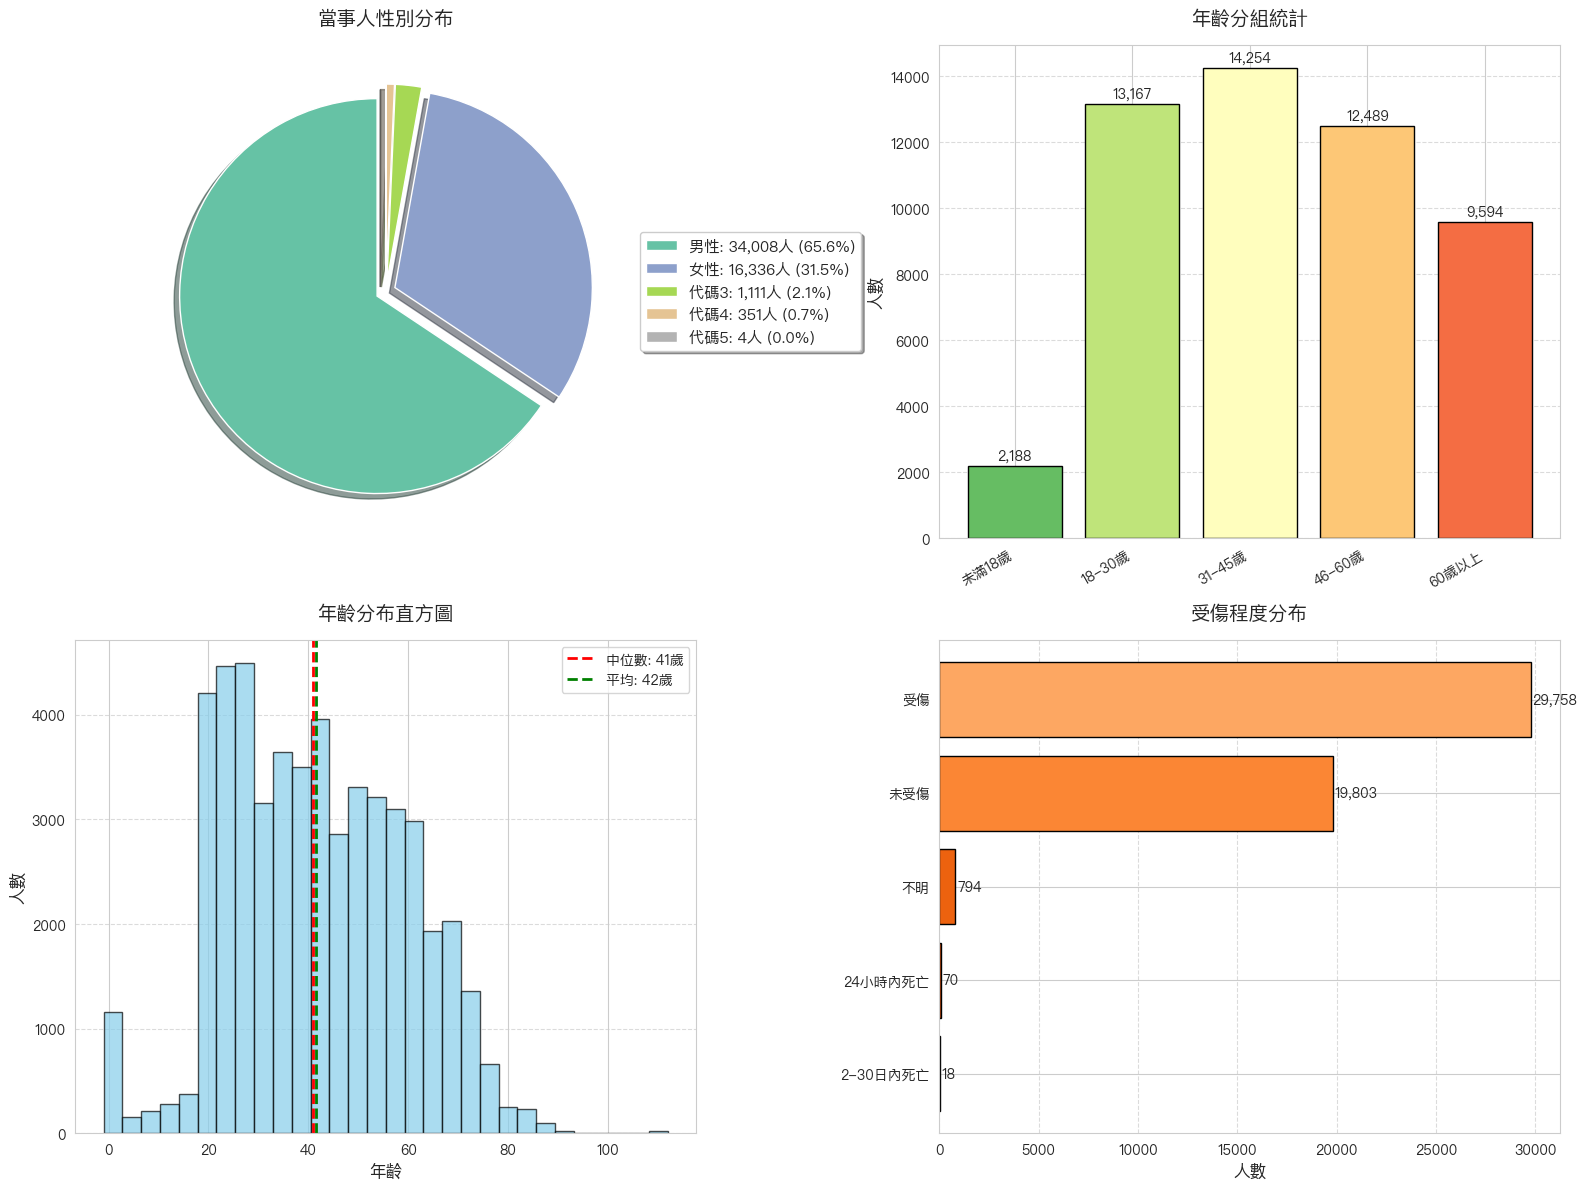

✓ 人員特性分析圖表已儲存


In [22]:
# 繪製人員特性圖表
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 性別圓餅圖
gender_labels = [gender_map.get(int(code), f'代碼{int(code)}') for code in gender_counts.index]
colors_gender = plt.cm.Set2(np.linspace(0, 1, len(gender_counts)))
explode_gender = [0.05] * len(gender_counts)

# 計算百分比用於圖例
percentages = (gender_counts / gender_counts.sum()) * 100
legend_labels = [f'{label}: {count:,}人 ({pct:.1f}%)' 
                 for label, count, pct in zip(gender_labels, gender_counts.values, percentages)]

wedges, texts = axes[0, 0].pie(gender_counts, labels=None, 
                                startangle=90, colors=colors_gender, explode=explode_gender,
                                shadow=True)
axes[0, 0].set_title('當事人性別分布', fontsize=14, fontweight='bold', pad=15)
axes[0, 0].legend(wedges, legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), 
                  fontsize=11, frameon=True, shadow=True)

# 年齡分組長條圖
colors_age = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(age_counts)))
bars = axes[0, 1].bar(range(len(age_counts)), age_counts.values, color=colors_age, edgecolor='black')
axes[0, 1].set_xticks(range(len(age_counts)))
axes[0, 1].set_xticklabels(age_counts.index, rotation=30, ha='right')
axes[0, 1].set_ylabel('人數', fontsize=12)
axes[0, 1].set_title('年齡分組統計', fontsize=14, fontweight='bold', pad=15)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

for bar, value in zip(bars, age_counts.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., value + 100,
                   f'{value:,}', ha='center', va='bottom', fontsize=10)

# 年齡直方圖
axes[1, 0].hist(df['年齡'].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('年齡', fontsize=12)
axes[1, 0].set_ylabel('人數', fontsize=12)
axes[1, 0].set_title('年齡分布直方圖', fontsize=14, fontweight='bold', pad=15)
median_age = df['年齡'].median()
mean_age = df['年齡'].mean()
axes[1, 0].axvline(median_age, color='red', linestyle='--', linewidth=2, label=f'中位數: {median_age:.0f}歲')
axes[1, 0].axvline(mean_age, color='green', linestyle='--', linewidth=2, label=f'平均: {mean_age:.0f}歲')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# 受傷程度統計
# 受傷程度代碼對照表（依據道路交通事故調查報告表 112.7.1 後適用版本）
injury_map = {
    1: '24小時內死亡',
    2: '受傷',
    3: '未受傷',
    4: '不明',
    5: '2-30日內死亡'
}
injury_counts = df['受傷程度'].value_counts().head(8)
colors_injury = plt.cm.Oranges(np.linspace(0.4, 0.9, len(injury_counts)))
axes[1, 1].barh(range(len(injury_counts)), injury_counts.values, color=colors_injury, edgecolor='black')
axes[1, 1].set_yticks(range(len(injury_counts)))
axes[1, 1].set_yticklabels([injury_map.get(int(code), f'代碼{int(code)}') for code in injury_counts.index])
axes[1, 1].set_xlabel('人數', fontsize=12)
axes[1, 1].set_title('受傷程度分布', fontsize=14, fontweight='bold', pad=15)
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', linestyle='--', alpha=0.7)

for i, value in enumerate(injury_counts.values):
    axes[1, 1].text(value + 100, i, f'{value:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('分析結果/圖表/07_人員特性分析.png', bbox_inches='tight')
plt.show()
print("✓ 人員特性分析圖表已儲存")


## 10. 綜合摘要報告


### 9.2 年齡分布進階分析

使用箱形圖與小提琴圖深入分析不同車種、行政區的當事人年齡分布特徵


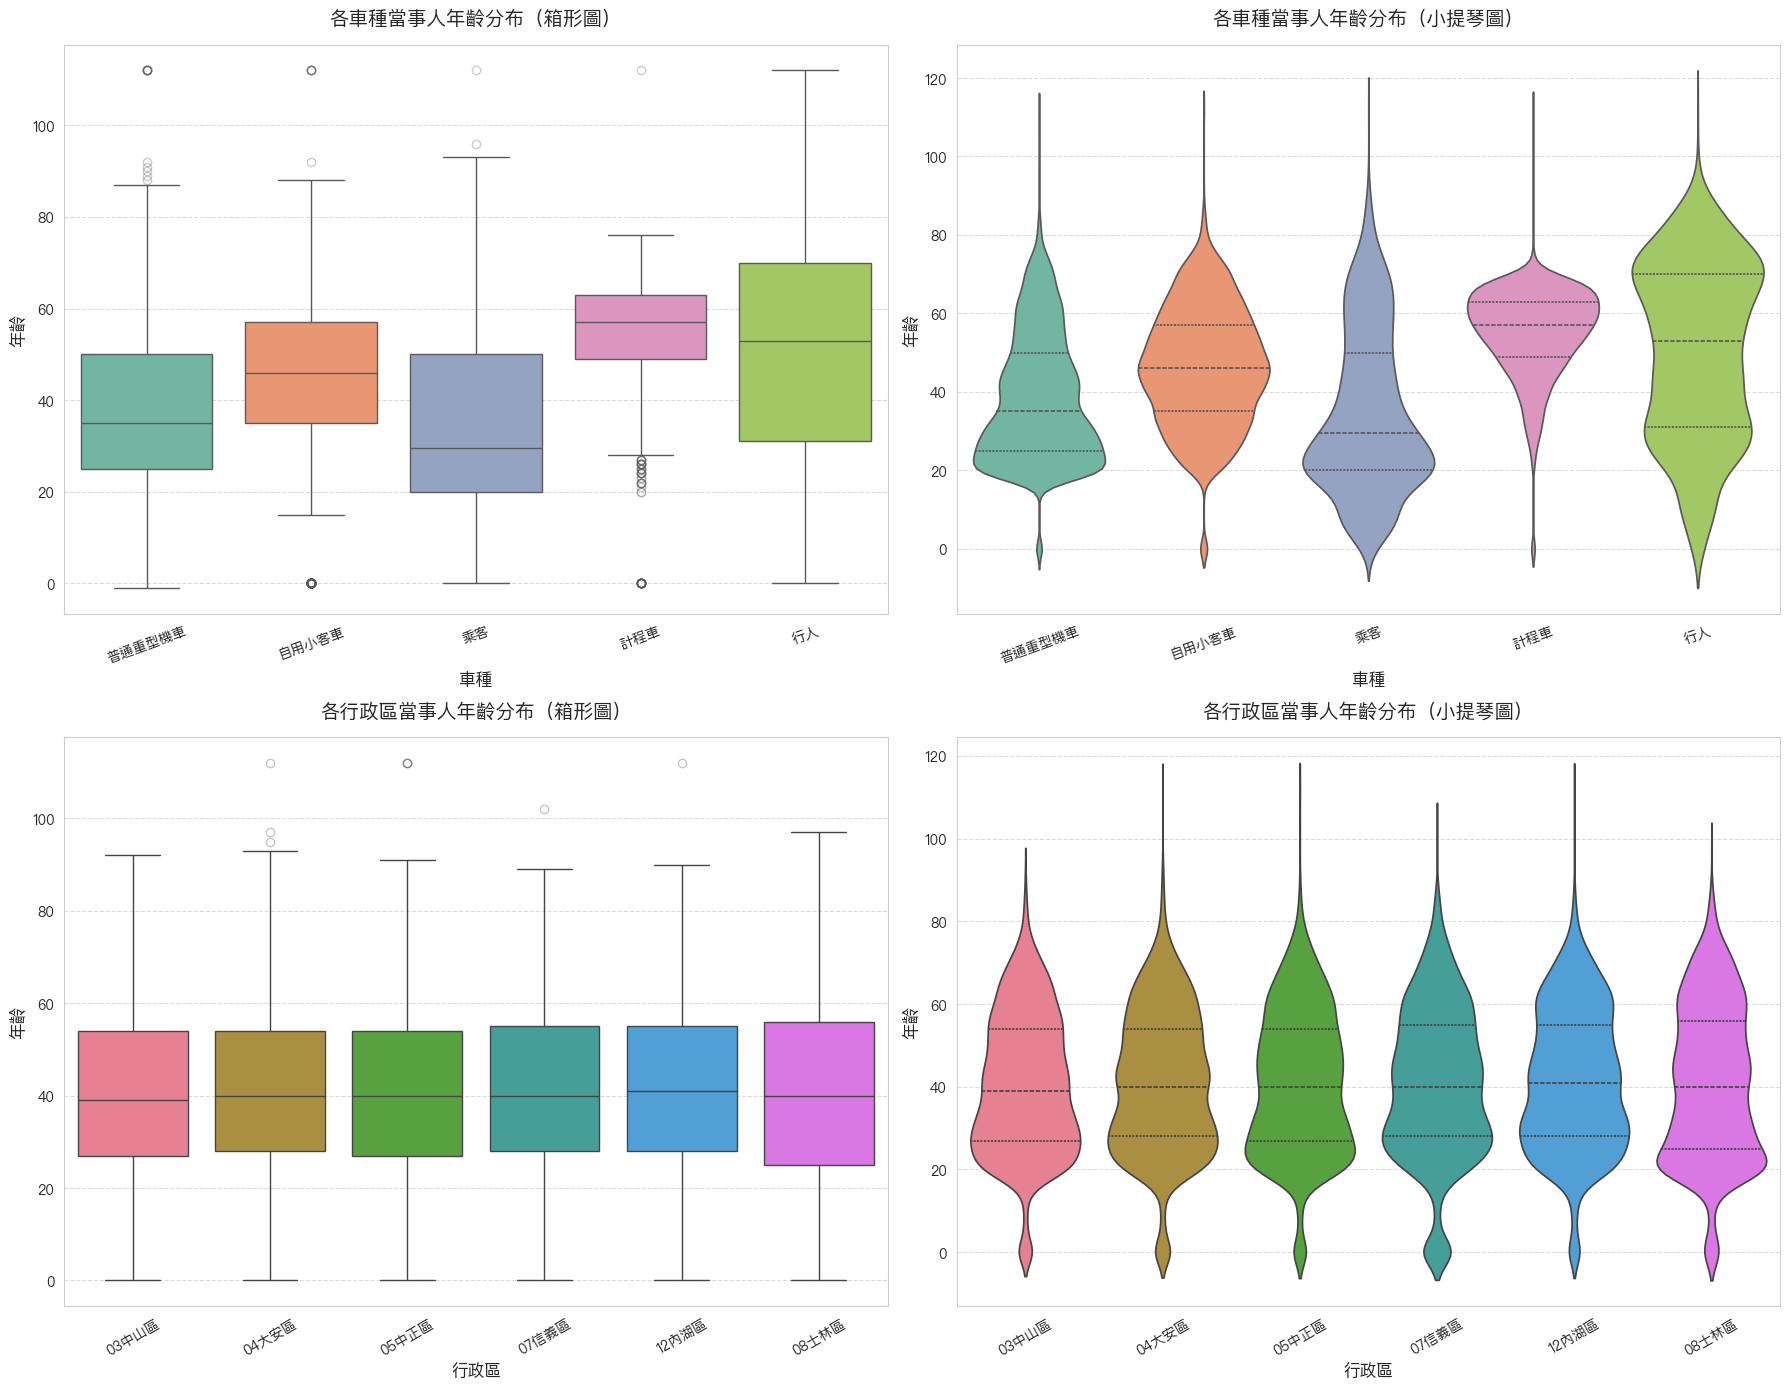

✓ 年齡分布進階分析圖表已儲存

📊 各車種年齡統計：
   普通重型機車: 中位數 35歲, 平均 38.6歲, 標準差 16.1
   自用小客車: 中位數 46歲, 平均 46.6歲, 標準差 15.0
   乘客: 中位數 30歲, 平均 34.9歲, 標準差 20.7
   計程車: 中位數 57歲, 平均 55.0歲, 標準差 11.1
   行人: 中位數 53歲, 平均 50.4歲, 標準差 22.4


In [23]:
# 準備分析資料
top5_vehicle_codes = df['車種'].value_counts().head(5).index.tolist()
df_top5_vehicle = df[df['車種'].isin(top5_vehicle_codes)].copy()
df_top5_vehicle['車種名稱'] = df_top5_vehicle['車種'].map(vehicle_map)

# 準備行政區資料（取事故件數前6區，使用 first_party 統計口徑）
top6_districts = first_party['區序'].value_counts().head(6).index.tolist()
df_top6_district = df[df['區序'].isin(top6_districts)].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 箱形圖 1：各車種年齡分布
order = [vehicle_map.get(code, code) for code in top5_vehicle_codes]
palette = sns.color_palette('Set2', len(top5_vehicle_codes))
sns.boxplot(x='車種名稱', y='年齡', data=df_top5_vehicle, ax=axes[0, 0],
            palette=palette, order=order, showfliers=True, flierprops={'alpha': 0.3})
axes[0, 0].set_title('各車種當事人年齡分布（箱形圖）', fontsize=14, fontweight='bold', pad=15)
axes[0, 0].set_xlabel('車種', fontsize=12)
axes[0, 0].set_ylabel('年齡', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# 小提琴圖 1：各車種年齡分布
sns.violinplot(x='車種名稱', y='年齡', data=df_top5_vehicle, ax=axes[0, 1],
               palette=palette, order=order, inner='quartile')
axes[0, 1].set_title('各車種當事人年齡分布（小提琴圖）', fontsize=14, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('車種', fontsize=12)
axes[0, 1].set_ylabel('年齡', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# 箱形圖 2：各行政區年齡分布
palette_district = sns.color_palette('husl', len(top6_districts))
sns.boxplot(x='區序', y='年齡', data=df_top6_district, ax=axes[1, 0],
            palette=palette_district, order=top6_districts, showfliers=True, flierprops={'alpha': 0.3})
axes[1, 0].set_title('各行政區當事人年齡分布（箱形圖）', fontsize=14, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('行政區', fontsize=12)
axes[1, 0].set_ylabel('年齡', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# 小提琴圖 2：各行政區年齡分布
sns.violinplot(x='區序', y='年齡', data=df_top6_district, ax=axes[1, 1],
               palette=palette_district, order=top6_districts, inner='quartile')
axes[1, 1].set_title('各行政區當事人年齡分布（小提琴圖）', fontsize=14, fontweight='bold', pad=15)
axes[1, 1].set_xlabel('行政區', fontsize=12)
axes[1, 1].set_ylabel('年齡', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('分析結果/圖表/10_年齡分布進階分析.png', bbox_inches='tight')
plt.show()
print("✓ 年齡分布進階分析圖表已儲存")

# 統計各車種年齡特徵
print("\n📊 各車種年齡統計：")
for code in top5_vehicle_codes:
    vehicle_data = df[df['車種'] == code]['年齡'].dropna()
    name = vehicle_map.get(code, code)
    print(f"   {name}: 中位數 {vehicle_data.median():.0f}歲, 平均 {vehicle_data.mean():.1f}歲, 標準差 {vehicle_data.std():.1f}")


### 9.3 甜甜圈圖與堆疊面積圖

使用甜甜圈圖呈現比例分布，堆疊面積圖呈現時間趨勢中的組成變化


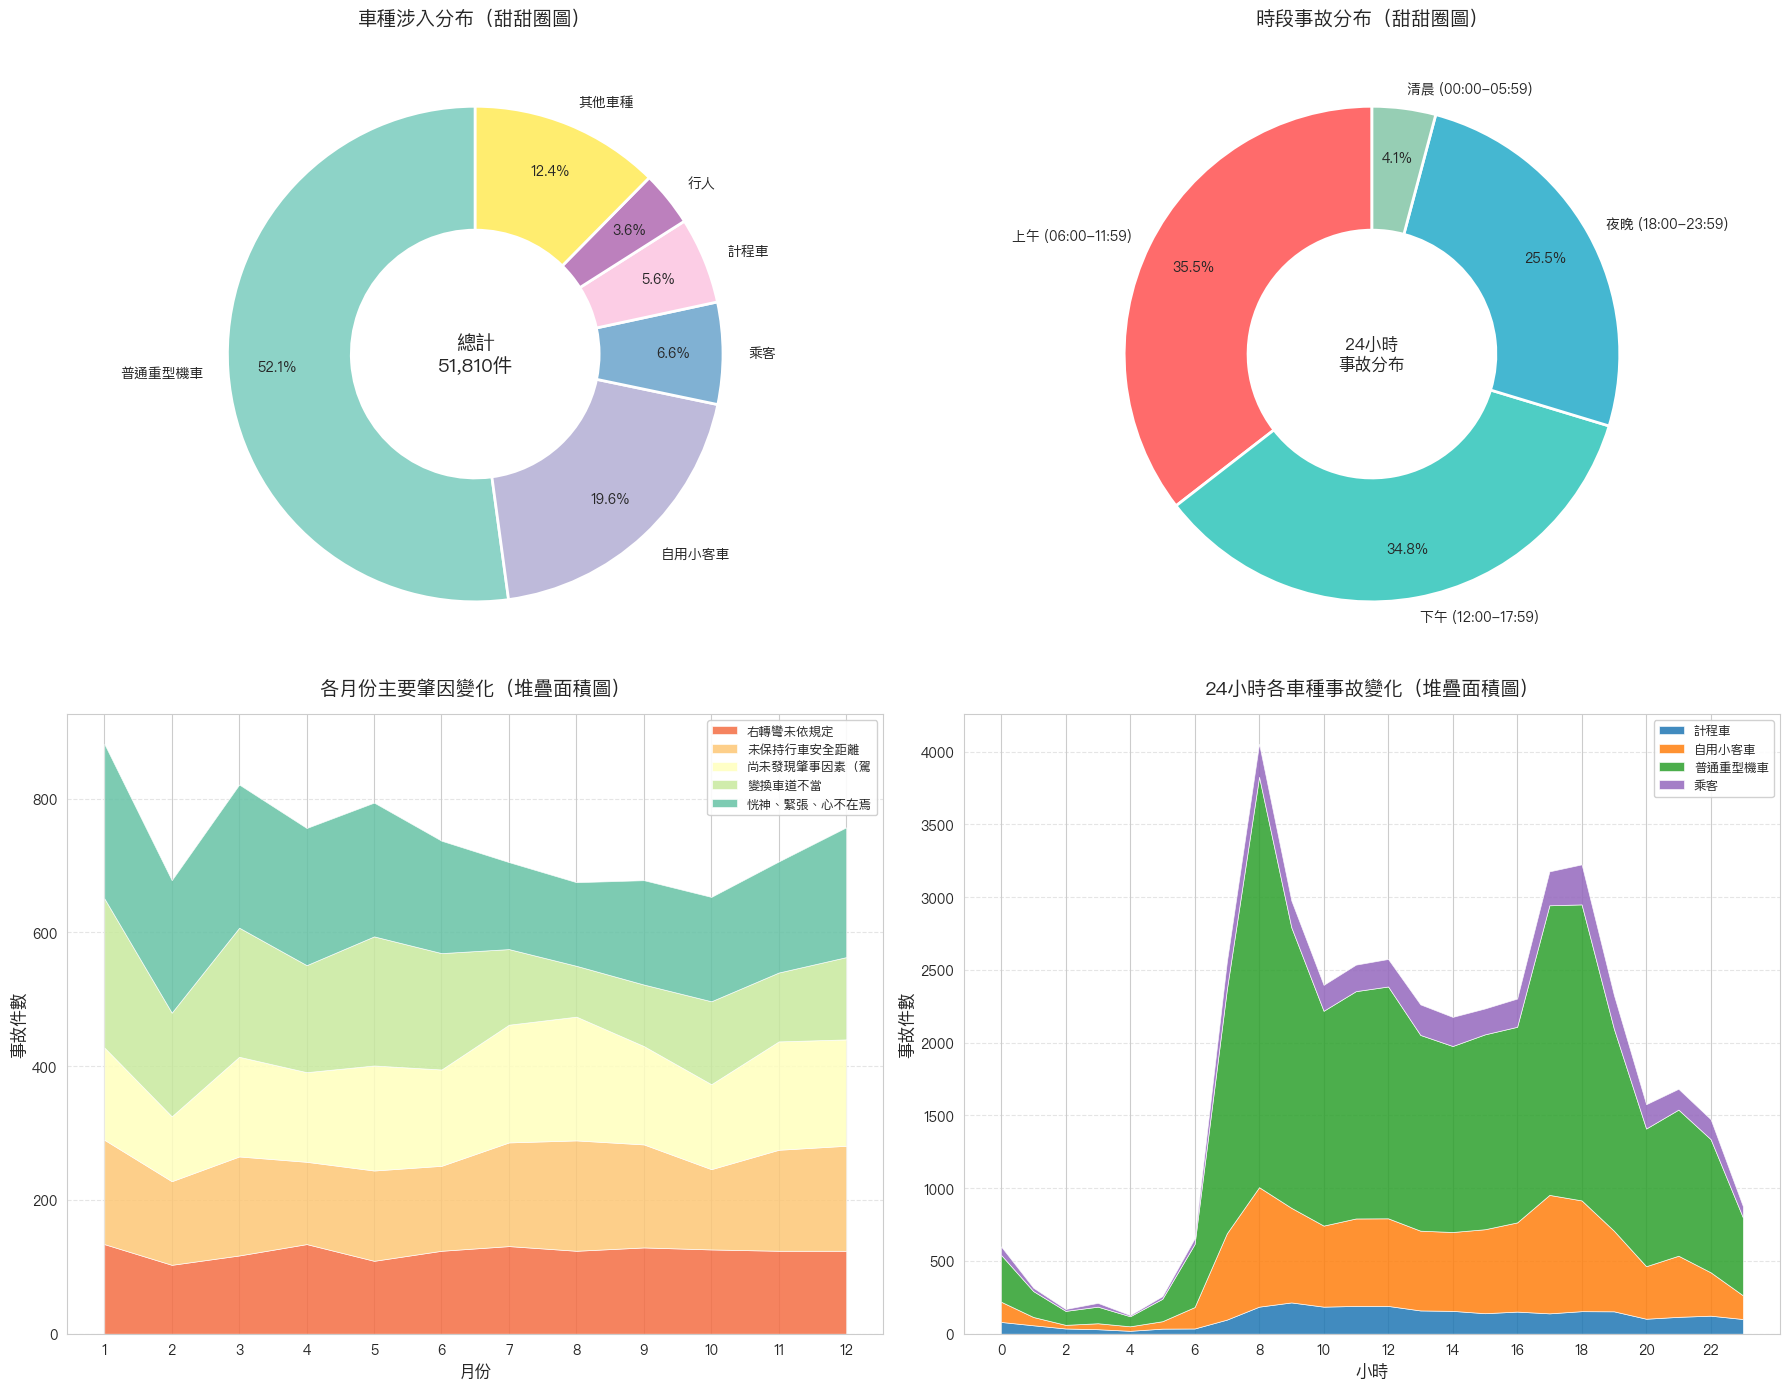

✓ 甜甜圈圖與堆疊面積圖已儲存


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ===== 甜甜圈圖 1：車種分布 =====
top5_vehicle = df['車種'].value_counts().head(5)
other_vehicle = df['車種'].value_counts()[5:].sum()
donut_data = pd.concat([top5_vehicle, pd.Series({'其他': other_vehicle})])
donut_labels = [vehicle_map.get(code, code) for code in donut_data.index[:5]] + ['其他車種']

colors_donut = plt.cm.Set3(np.linspace(0, 1, 6))
wedges, texts, autotexts = axes[0, 0].pie(donut_data, labels=donut_labels, autopct='%1.1f%%',
                                           startangle=90, colors=colors_donut, 
                                           pctdistance=0.8, labeldistance=1.1,
                                           wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
                                           textprops={'fontsize': 10})
# 中心文字
centre_circle = plt.Circle((0, 0), 0.35, fc='white')
axes[0, 0].add_patch(centre_circle)
axes[0, 0].text(0, 0, f'總計\n{len(df):,}件', ha='center', va='center', 
                fontsize=14, fontweight='bold')
axes[0, 0].set_title('車種涉入分布（甜甜圈圖）', fontsize=14, fontweight='bold', pad=15)

# ===== 甜甜圈圖 2：時段分布（使用 first_party）=====
time_counts = first_party['時段'].value_counts()
colors_time = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
wedges2, texts2, autotexts2 = axes[0, 1].pie(time_counts, labels=time_counts.index, autopct='%1.1f%%',
                                              startangle=90, colors=colors_time,
                                              pctdistance=0.8, labeldistance=1.08,
                                              wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
                                              textprops={'fontsize': 10})
centre_circle2 = plt.Circle((0, 0), 0.35, fc='white')
axes[0, 1].add_patch(centre_circle2)
axes[0, 1].text(0, 0, f'24小時\n事故分布', ha='center', va='center', 
                fontsize=12, fontweight='bold')
axes[0, 1].set_title('時段事故分布（甜甜圈圖）', fontsize=14, fontweight='bold', pad=15)

# ===== 堆疊面積圖 1：月份 × 肇因（使用 first_party）=====
# 取前5大肇因（使用第一當事人統計）
top5_causes = first_party['肇因碼-個別'].value_counts().head(5).index.tolist()
monthly_cause = first_party[first_party['肇因碼-個別'].isin(top5_causes)].groupby(['發生月', '肇因碼-個別']).size().unstack(fill_value=0)
monthly_cause.columns = [cause_map.get(str(int(col)), f'代碼{int(col)}')[:10] for col in monthly_cause.columns]

colors_stack = plt.cm.Spectral(np.linspace(0.2, 0.8, len(monthly_cause.columns)))
axes[1, 0].stackplot(monthly_cause.index, monthly_cause.T.values, labels=monthly_cause.columns,
                      colors=colors_stack, alpha=0.85, edgecolor='white', linewidth=0.5)
axes[1, 0].set_title('各月份主要肇因變化（堆疊面積圖）', fontsize=14, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('月份', fontsize=12)
axes[1, 0].set_ylabel('事故件數', fontsize=12)
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].legend(loc='upper right', fontsize=9, framealpha=0.9)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

# ===== 堆疊面積圖 2：小時 × 車種 =====
top4_vehicles = df['車種'].value_counts().head(4).index.tolist()
hourly_vehicle = df[df['車種'].isin(top4_vehicles)].groupby(['發生時-Hours', '車種']).size().unstack(fill_value=0)
hourly_vehicle.columns = [vehicle_map.get(col, col) for col in hourly_vehicle.columns]

colors_stack2 = plt.cm.tab10(np.linspace(0, 0.4, len(hourly_vehicle.columns)))
axes[1, 1].stackplot(hourly_vehicle.index, hourly_vehicle.T.values, labels=hourly_vehicle.columns,
                      colors=colors_stack2, alpha=0.85, edgecolor='white', linewidth=0.5)
axes[1, 1].set_title('24小時各車種事故變化（堆疊面積圖）', fontsize=14, fontweight='bold', pad=15)
axes[1, 1].set_xlabel('小時', fontsize=12)
axes[1, 1].set_ylabel('事故件數', fontsize=12)
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].legend(loc='upper right', fontsize=9, framealpha=0.9)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('分析結果/圖表/11_甜甜圈與堆疊面積圖.png', bbox_inches='tight')
plt.show()
print("✓ 甜甜圈圖與堆疊面積圖已儲存")


In [25]:
print("\n【步驟10】產生分析摘要報告...")

# 計算總傷亡人數
total_casualties = int(total_deaths + total_2_30_deaths + total_injuries)

summary = []
summary.append("="*80)
summary.append("113年臺北市A1及A2類交通事故分析摘要報告")
summary.append("="*80)
summary.append("")
summary.append("【資料概況】（與官方報告一致）")
summary.append(f"  - A1類事故：{a1_count} 件")
summary.append(f"  - A2類事故：{a2_count:,} 件")
summary.append(f"  - 總事故件數：{accident_count:,} 件")
summary.append(f"  - 總死亡人數：{int(total_deaths + total_2_30_deaths):,} 人（24小時內{int(total_deaths)}人 + 2-30日{int(total_2_30_deaths)}人）")
summary.append(f"  - 總受傷人數：{int(total_injuries):,} 人")
summary.append(f"  - 總傷亡人數：{total_casualties:,} 人（死亡{int(total_deaths + total_2_30_deaths)}人 + 受傷{int(total_injuries):,}人）")
summary.append("")

summary.append("【時間分析】")
month_counts = first_party['發生月'].value_counts().sort_index()
hour_counts = first_party['發生時-Hours'].value_counts().sort_index()
summary.append(f"  - 事故最多月份：{month_counts.idxmax()}月 ({month_counts.max():,}件)")
summary.append(f"  - 事故最少月份：{month_counts.idxmin()}月 ({month_counts.min():,}件)")
summary.append(f"  - 月均事故件數：{month_counts.mean():.0f} 件")
summary.append(f"  - 高峰時段：{hour_counts.idxmax()}時 ({hour_counts.max():,}件)")
summary.append("")

summary.append("【空間分析】（僅A1+A2類）")
district_counts = first_party['區序'].value_counts()
summary.append("  - 事故最多前5區：")
for rank, (district, count) in enumerate(district_counts.head(5).items(), 1):
    pct = count / accident_count * 100
    summary.append(f"    {rank}. {district}: {count:,}件 ({pct:.1f}%)")
summary.append(f"  - 前5區合計佔比：{district_counts.head(5).sum()/accident_count*100:.1f}%")
summary.append("")

summary.append("【肇因分析】（第一當事人統計）")
summary.append("  - 主要肇因前5名：")
for rank, (code, count) in enumerate(cause_counts.head(5).items(), 1):
    code_str = str(int(code))
    cause_name = cause_map.get(code_str, f'代碼{code_str}')
    pct = count / accident_count * 100
    summary.append(f"    {rank}. [{code_str}] {cause_name}: {count:,}件 ({pct:.1f}%)")
summary.append(f"  - 前5肇因累計佔比：{cause_counts.head(5).sum()/accident_count*100:.1f}%")
summary.append("")

summary.append("【車種分析】")
vehicle_counts = df['車種'].value_counts()
summary.append("  - 主要涉入車種前5名：")
for rank, (code, count) in enumerate(vehicle_counts.head(5).items(), 1):
    vehicle_name = vehicle_map.get(code, code)
    # ⚠️ 佔比計算使用「有車種記錄的當事人」為分母，與圓餅圖一致
    pct = count / vehicle_counts.sum() * 100
    summary.append(f"    {rank}. [{code}] {vehicle_name}: {count:,}件 ({pct:.1f}%)")
summary.append("")

summary.append("【關鍵發現】")
summary.append("  1. 分心駕駛為第一大肇因：代碼108佔9.6%")
summary.append("  2. 事故高度集中：前5區佔全市A1+A2事故55%")
summary.append("  3. 下午通勤時段為高峰：17時為單一小時最高峰")
summary.append("")

summary.append("="*80)
summary.append("📊 本分析採用與官方報告一致的統計方式")
summary.append("   （以事故件數為單位，肇因僅統計第一當事人）")
summary.append("="*80)

print("\n".join(summary))

# 儲存摘要報告
with open('分析結果/分析摘要.txt', 'w', encoding='utf-8') as f:
    f.write("\n".join(summary))
print("\n✓ 分析摘要已儲存至 分析結果/分析摘要.txt")



【步驟10】產生分析摘要報告...
113年臺北市A1及A2類交通事故分析摘要報告

【資料概況】（與官方報告一致）
  - A1類事故：68 件
  - A2類事故：22,300 件
  - 總事故件數：22,368 件
  - 總死亡人數：74 人（24小時內70人 + 2-30日4人）
  - 總受傷人數：29,774 人
  - 總傷亡人數：29,848 人（死亡74人 + 受傷29,774人）

【時間分析】
  - 事故最多月份：1月 (2,089件)
  - 事故最少月份：2月 (1,600件)
  - 月均事故件數：1864 件
  - 高峰時段：8時 (2,025件)

【空間分析】（僅A1+A2類）
  - 事故最多前5區：
    1. 03中山區: 2,932件 (13.1%)
    2. 04大安區: 2,384件 (10.7%)
    3. 05中正區: 2,207件 (9.9%)
    4. 07信義區: 2,148件 (9.6%)
    5. 12內湖區: 2,088件 (9.3%)
  - 前5區合計佔比：52.6%

【肇因分析】（第一當事人統計）
  - 主要肇因前5名：
    1. [108] 恍神、緊張、心不在焉分心駕駛: 2,143件 (9.6%)
    2. [44] 尚未發現肇事因素（駕駛者）: 1,775件 (7.9%)
    3. [100] 變換車道不當: 1,729件 (7.7%)
    4. [16] 未保持行車安全距離: 1,716件 (7.7%)
    5. [9] 右轉彎未依規定: 1,479件 (6.6%)
  - 前5肇因累計佔比：39.5%

【車種分析】
  - 主要涉入車種前5名：
    1. [C03] 普通重型機車: 26,539件 (52.1%)
    2. [B03] 自用小客車: 9,966件 (19.6%)
    3. [H02] 乘客: 3,380件 (6.6%)
    4. [B01] 計程車: 2,866件 (5.6%)
    5. [H01] 行人: 1,833件 (3.6%)

【關鍵發現】
  1. 分心駕駛為第一大肇因：代碼108佔9.6%
  2. 事故高度集中：前5區佔全市A1+A2事故55%
  3. 下午通勤時段為高峰：17時為單

## 分析完成

---

所有結果已儲存至「**分析結果**」資料夾：
- **統計表**：`分析結果/統計表/`
- **圖表**：`分析結果/圖表/`
- **摘要報告**：`分析結果/分析摘要.txt`

## 待整合

【每月天氣事故統計】
     total_accidents  rainy_accidents   rain_pct
發生月                                             
1               2089              243  11.632360
2               1600              157   9.812500
3               1911              334  17.477760
4               1764              258  14.625850
5               1943              225  11.580031
6               1781              282  15.833801
7               1828              198  10.831510
8               1913              140   7.318348
9               1934              322  16.649431
10              1737              511  29.418538
11              1863              480  25.764895
12              2005              230  11.471322


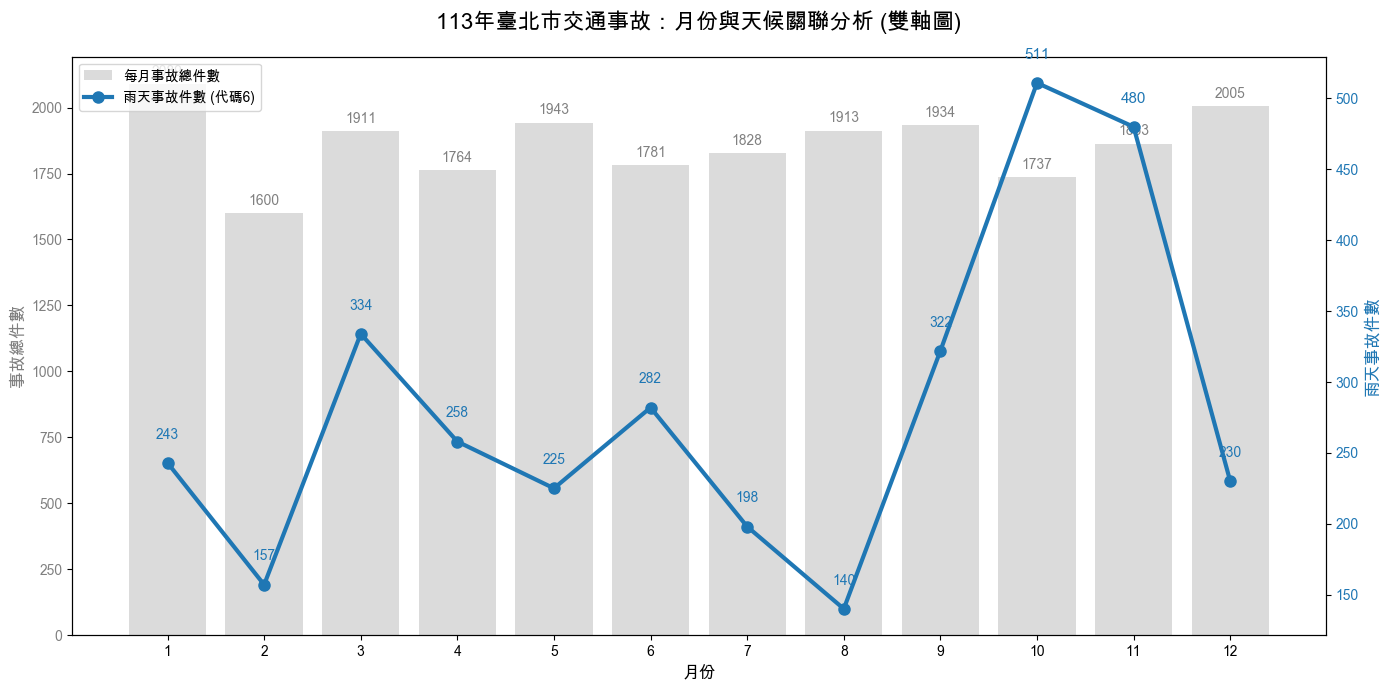

In [2]:
# ---------------------------------------------------------
# [新增分析] 月份與天氣關聯分析 (雙軸圖)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import pandas as pd

# 1. 設定中文字型 (針對 macOS 與 Windows 的相容設定)
import platform
system_name = platform.system()
if system_name == 'Darwin':  # macOS
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang TC', 'Heiti TC']
elif system_name == 'Windows':  # Windows
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Taipei Sans TC Beta']
else:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 重新讀取資料 (使用 cp950 解決 UnicodeDecodeError)
# 注意：若前方程式碼已讀取過 df，可省略此行，但建議確保資料是最新的
try:
    df_weather = pd.read_csv('113年-臺北市A1及A2類交通事故明細.csv', encoding='cp950')
except:
    # 備用方案：嘗試 big5
    df_weather = pd.read_csv('113年-臺北市A1及A2類交通事故明細.csv', encoding='big5')

# 3. 資料前處理
# 篩選單一事故 (避免重複計算)
df_unique_accidents = df_weather[df_weather['當事人序號'] == 1].copy()

# 統計每月數據
# 天候代碼 6 = 雨天 (根據警政署標準與資料分佈推測)
monthly_stats = df_unique_accidents.groupby('發生月').agg(
    total_accidents=('處理別-編號', 'size'),
    rainy_accidents=('天候', lambda x: (x == 6).sum())
).sort_index()

# 計算雨天佔比 (Optional, print 出來參考)
monthly_stats['rain_pct'] = monthly_stats['rainy_accidents'] / monthly_stats['total_accidents'] * 100
print("【每月天氣事故統計】")
print(monthly_stats)

# 4. 繪製雙軸圖
fig, ax1 = plt.subplots(figsize=(14, 7))

# 左軸：總事故件數 (長條圖)
color_bar = '#d3d3d3'  # 淺灰色
bars = ax1.bar(monthly_stats.index, monthly_stats['total_accidents'], color=color_bar, alpha=0.8, label='每月事故總件數')
ax1.set_xlabel('月份', fontsize=12)
ax1.set_ylabel('事故總件數', fontsize=12, color='gray')
ax1.tick_params(axis='y', labelcolor='gray')
ax1.set_xticks(range(1, 13))

# 在長條圖上方標註數值
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{int(height)}',
             ha='center', va='bottom', color='gray', fontsize=10)

# 右軸：雨天事故件數 (折線圖)
ax2 = ax1.twinx()
color_line = '#1f77b4'  # 藍色
line = ax2.plot(monthly_stats.index, monthly_stats['rainy_accidents'], 
                color=color_line, marker='o', linewidth=3, markersize=8, label='雨天事故件數 (代碼6)')
ax2.set_ylabel('雨天事故件數', fontsize=12, color=color_line, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line)

# 在折線圖上方標註數值 (特別標註高峰)
for x, y in zip(monthly_stats.index, monthly_stats['rainy_accidents']):
    # 針對 10月, 11月 高峰加粗顯示
    font_weight = 'bold' if y > 400 else 'normal'
    font_size = 11 if y > 400 else 10
    ax2.text(x, y + 15, f'{y}', ha='center', va='bottom', color=color_line, 
             fontsize=font_size, fontweight=font_weight)

# 圖表標題與排版
plt.title('113年臺北市交通事故：月份與天候關聯分析 (雙軸圖)', fontsize=16, pad=20)
plt.grid(True, axis='x', linestyle='--', alpha=0.3)

# 合併圖例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()